In [2]:
# SECTION 0: Environment setup and imports
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError('xgboost is required. Install with: pip install xgboost') from exc

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')

RANDOM_STATE = 42
TEST_SIZE = 0.20

ROOT = Path('.')
MAIN_DATA_CANDIDATES = [
    ROOT / 'survey_and_operational_data.parquet',
    ROOT / '../survey_and_operational_data.parquet',
    Path('/Users/macpro/Documents/thesis/survey_and_operational_data.parquet'),
]
MAIN_DATA_PATH = next((p for p in MAIN_DATA_CANDIDATES if p.exists()), None)
if MAIN_DATA_PATH is None:
    checked = [str(p.resolve()) for p in MAIN_DATA_CANDIDATES]
    raise FileNotFoundError(f'Could not find main dataset. Checked: {checked}')

print('Main dataset:', MAIN_DATA_PATH.resolve())

Main dataset: /Users/macpro/Documents/thesis/survey_and_operational_data.parquet


In [3]:
# SECTION 1: Data inventory and size diagnostics
def csv_shape_fast(path: Path):
    if not path.exists():
        return None, None
    try:
        cols = pd.read_csv(path, nrows=0).shape[1]
        rows = max(sum(1 for _ in open(path, 'r', encoding='utf-8', errors='ignore')) - 1, 0)
        return rows, cols
    except Exception:
        return np.nan, np.nan

main_df = pd.read_parquet(MAIN_DATA_PATH).copy()

inventory_rows = [
    {
        'Source': 'survey_and_operational_data.parquet',
        'Type': 'Main merged survey + operational modeling table',
        'Rows': int(main_df.shape[0]),
        'Columns': int(main_df.shape[1]),
    }
]

survey_csv = Path('survey_responses.csv')
if survey_csv.exists():
    s_rows, s_cols = csv_shape_fast(survey_csv)
    inventory_rows.append({
        'Source': str(survey_csv),
        'Type': 'Survey responses raw/processed extract',
        'Rows': s_rows,
        'Columns': s_cols,
    })

operational_csv_candidates = [
    Path('data/operational/maintenance_and_restrictions/maintenance_and_restrictions__fct_corrective_maintenance.csv'),
    Path('data/operational/maintenance_and_restrictions/maintenance_and_restrictions__fct_preventive_maintenance.csv'),
    Path('data/operational/maintenance_and_restrictions/maintenance_and_restrictions__fct_restrictions.csv'),
]

for p in operational_csv_candidates:
    if p.exists():
        o_rows, o_cols = csv_shape_fast(p)
        inventory_rows.append({
            'Source': str(p),
            'Type': 'Operational source table',
            'Rows': o_rows,
            'Columns': o_cols,
        })

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)

print('Main table row count:', f"{len(main_df):,}")
print('Main table column count:', f"{main_df.shape[1]:,}")

,Source,Type,Rows,Columns
0,survey_and_operational_data.parquet,Main merged survey + operational modeling table,178833,211


Main table row count: 178,833
Main table column count: 211


In [4]:
# SECTION 2: Variable mapping, cleaning policy, and diagnostics
TARGET_NPS = 'metadata_recommendation_nps_a'
DELAY_VAR = 'arrival_delay_minute'

SURVEY_VARS = [
    'question_overall_satisfaction_wifi_onboard_the_train',
    'question_on_board_the_train1_the_temperature_on_board',
    'question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train',
    'question_on_board_the_train1_the_availability_of_toilet_facilities_on_board',
    'question_onboard_catering_met_quality_of_food_in_meal_service',
    'question_overall_satisfaction_cleanliness_onboard_the_train',
    'question_overall_satisfaction_overall_service_from_eurostar_staff',
]

OBJECTIVE_VARS = [
    'total_restrictions',
    'restriction_open_Toilets',
    'restriction_open_Air Conditioning',
    'restriction_open_WiFi',
    'restriction_open_Refrigeration',
    'last_clean_score',
    'hours_since_last_clean',
    'equipment_type',
]

required = [TARGET_NPS, DELAY_VAR] + SURVEY_VARS
missing_required = [c for c in required if c not in main_df.columns]
if missing_required:
    raise KeyError(f'Missing required thesis columns: {missing_required}')

df = main_df.copy()

# Ensure objective columns exist with robust fallback handling
for c in OBJECTIVE_VARS:
    if c not in df.columns:
        df[c] = np.nan if c != 'equipment_type' else 'Unknown'

if df['total_restrictions'].isna().all():
    parts = [
        'restriction_open_Toilets',
        'restriction_open_Air Conditioning',
        'restriction_open_WiFi',
        'restriction_open_Refrigeration',
    ]
    df['total_restrictions'] = df[parts].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)

# Missing policy
df[TARGET_NPS] = pd.to_numeric(df[TARGET_NPS], errors='coerce')
df[DELAY_VAR] = pd.to_numeric(df[DELAY_VAR], errors='coerce')
df = df.dropna(subset=[TARGET_NPS, DELAY_VAR]).copy()

# Survey: median imputation only (no missing-indicator features)
for c in SURVEY_VARS:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    median_val = df[c].median()
    if pd.isna(median_val):
        median_val = 0.0
    df[c] = df[c].fillna(median_val)

for c in [
    'total_restrictions',
    'restriction_open_Toilets',
    'restriction_open_Air Conditioning',
    'restriction_open_WiFi',
    'restriction_open_Refrigeration',
    'last_clean_score',
    'hours_since_last_clean',
]:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# Binary train generation: new=1 (RUB/E320), old=0 (TGH/E300); fallback unknown=-1
df['equipment_type'] = df['equipment_type'].astype('string').str.upper().fillna('UNKNOWN')
new_equipment = {'RUB', 'E320'}
old_equipment = {'TGH', 'E300'}
df['equipment_new_binary'] = np.select(
    [df['equipment_type'].isin(new_equipment), df['equipment_type'].isin(old_equipment)],
    [1, 0],
    default=-1,
).astype(int)

key_vars = [TARGET_NPS, DELAY_VAR] + SURVEY_VARS + OBJECTIVE_VARS + ['equipment_new_binary']
missing_table = df[key_vars].isna().sum().to_frame('missing_count')
missing_table['missing_pct'] = (missing_table['missing_count'] / len(df) * 100).round(3)

print('Modeling-ready rows after strict target/delay filtering:', f"{len(df):,}")
print('Equipment binary counts (new=1, old=0, unknown=-1):')
display(df['equipment_new_binary'].value_counts(dropna=False).rename('count').to_frame())
display(missing_table.sort_values('missing_pct', ascending=False))

Modeling-ready rows after strict target/delay filtering: 178,833
Equipment binary counts (new=1, old=0, unknown=-1):


,count
equipment_new_binary,
1,98624
0,80209


,missing_count,missing_pct
metadata_recommendation_nps_a,0,0.0
arrival_delay_minute,0,0.0
equipment_type,0,0.0
hours_since_last_clean,0,0.0
last_clean_score,0,0.0
restriction_open_Refrigeration,0,0.0
restriction_open_WiFi,0,0.0
restriction_open_Air Conditioning,0,0.0
restriction_open_Toilets,0,0.0
total_restrictions,0,0.0


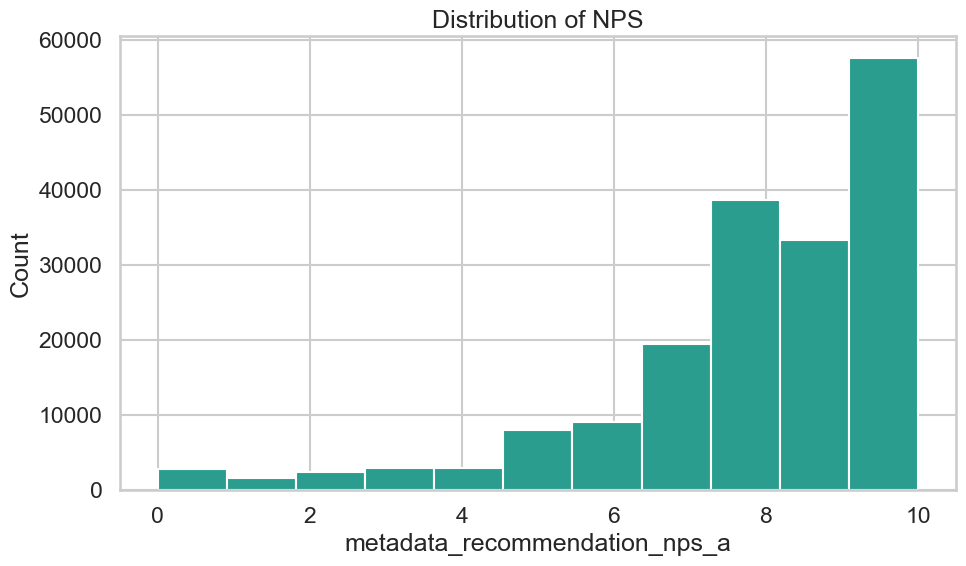

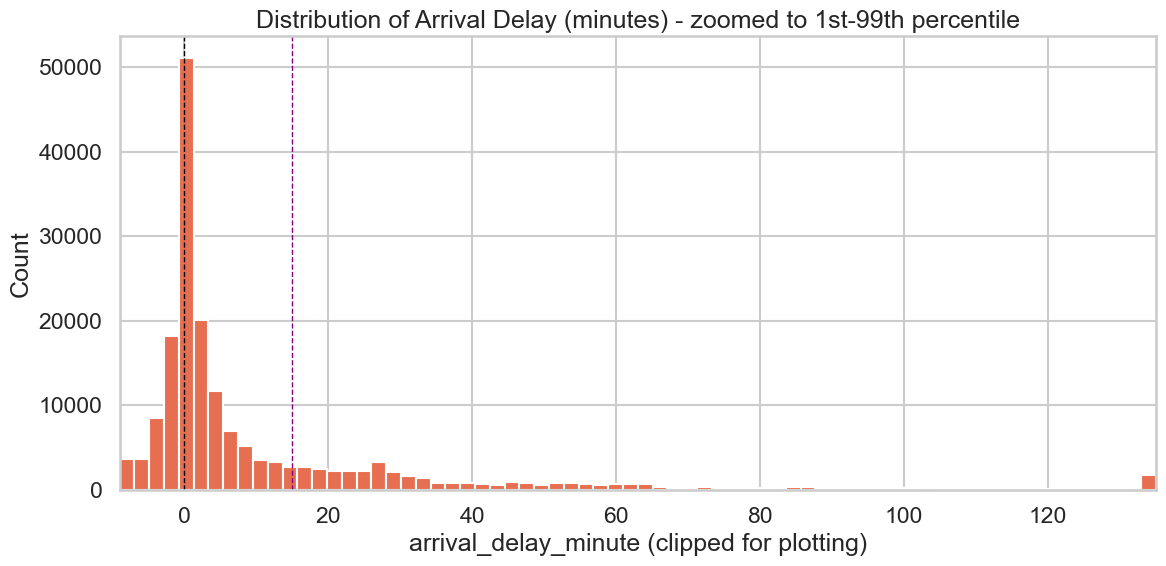

<Figure size 1000x600 with 0 Axes>

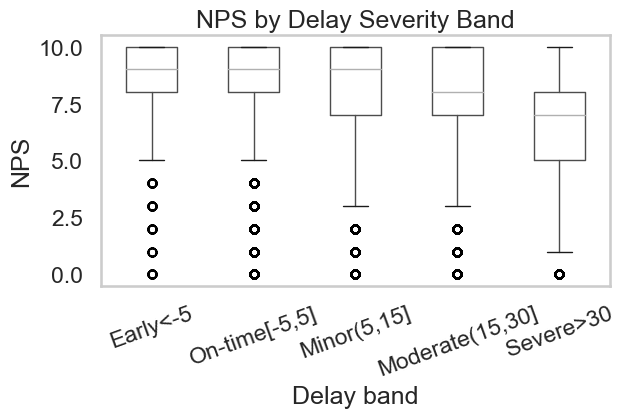

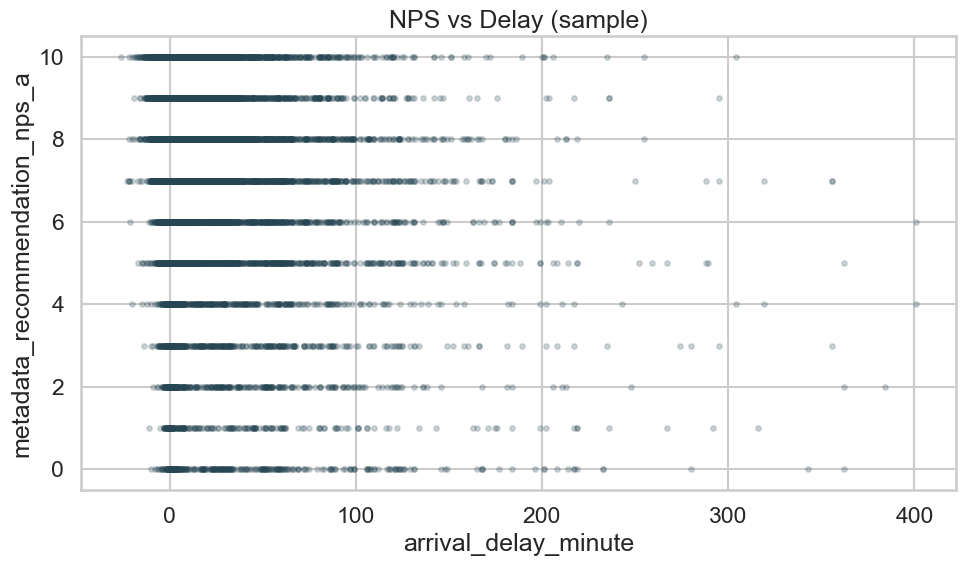

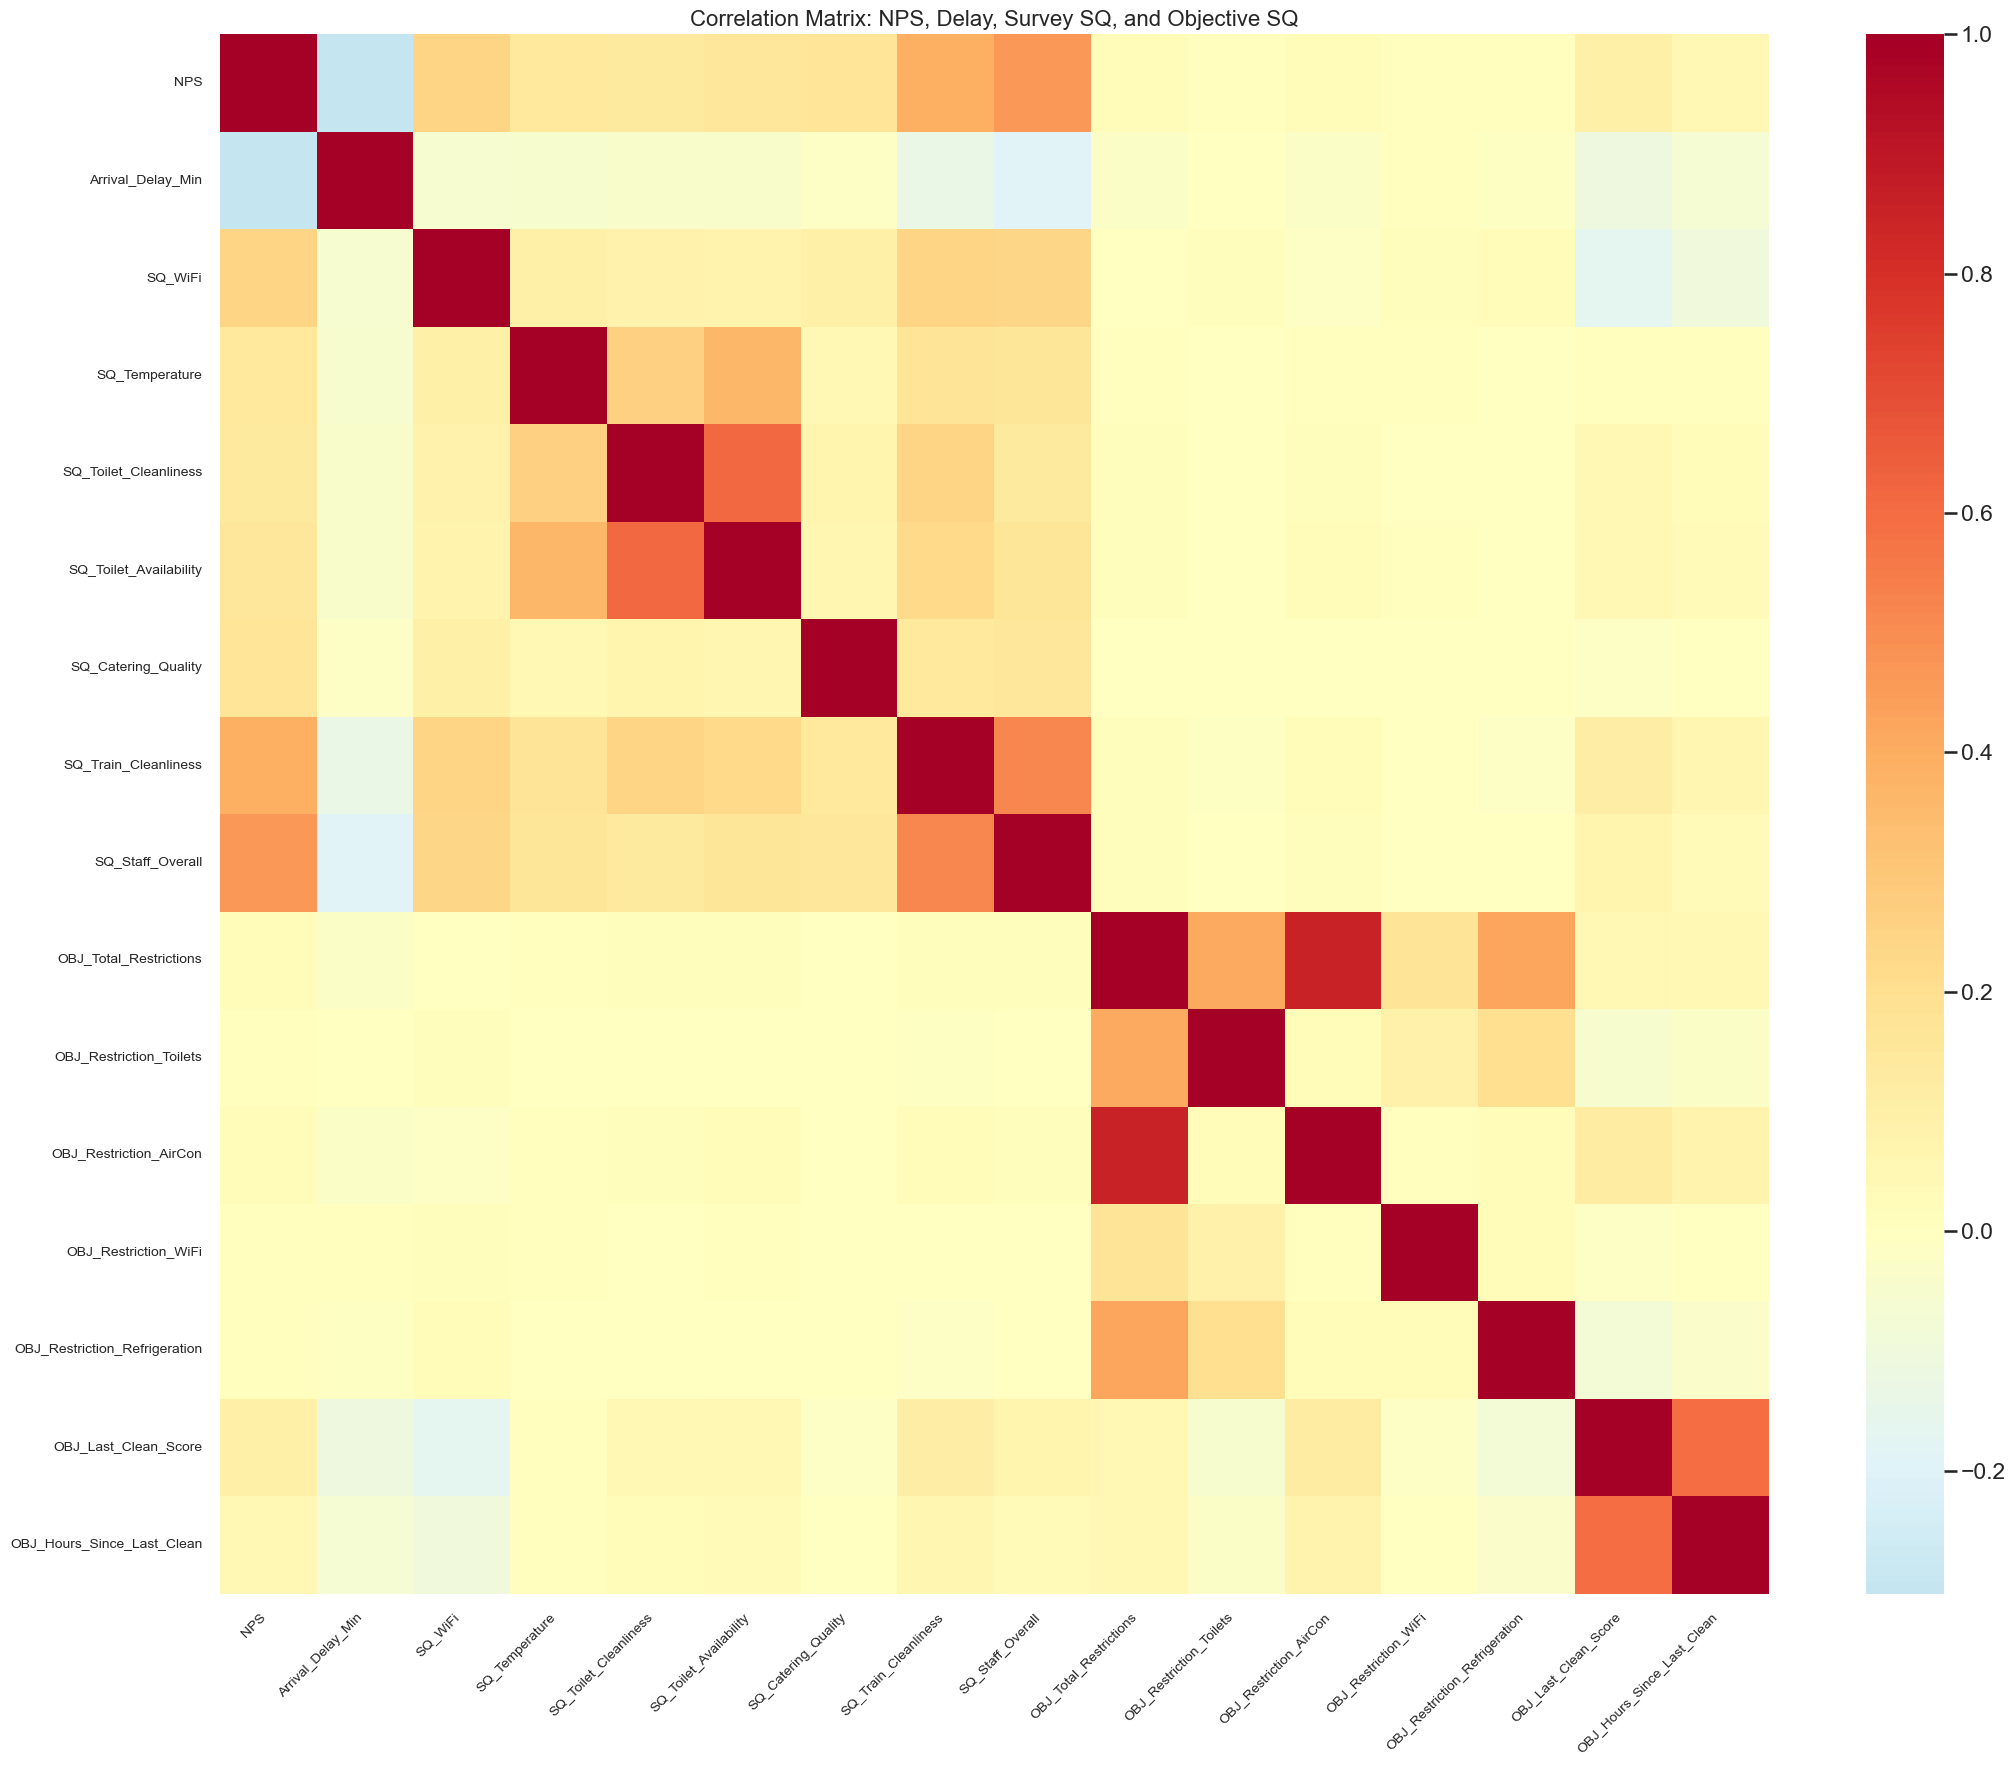

In [5]:
# SECTION 3: Detailed visualization and data understanding (single-chart windows)

# 3.1 Distribution of NPS
plt.figure(figsize=(10, 6))
pd.Series(df[TARGET_NPS]).dropna().hist(bins=11, color='#2a9d8f', edgecolor='white')
plt.title('Distribution of NPS')
plt.xlabel(TARGET_NPS)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3.2 Distribution of arrival delay (zoomed to central mass for readability)
delay_series = pd.to_numeric(df[DELAY_VAR], errors='coerce').dropna()
q_low, q_high = delay_series.quantile([0.01, 0.99])
delay_zoom = delay_series.clip(lower=q_low, upper=q_high)

plt.figure(figsize=(12, 6))
plt.hist(delay_zoom, bins=70, color='#e76f51', edgecolor='white')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(15, color='purple', linestyle='--', linewidth=1)
plt.xlim(q_low, q_high)
plt.title('Distribution of Arrival Delay (minutes) - zoomed to 1st-99th percentile')
plt.xlabel(f'{DELAY_VAR} (clipped for plotting)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3.3 NPS by delay severity band
delay_bins = pd.cut(
    df[DELAY_VAR],
    bins=[-120, -5, 5, 15, 30, 999],
    labels=['Early<-5', 'On-time[-5,5]', 'Minor(5,15]', 'Moderate(15,30]', 'Severe>30']
)
tmp_box = pd.DataFrame({'delay_band': delay_bins, 'nps': df[TARGET_NPS]}).dropna()

plt.figure(figsize=(10, 6))
tmp_box.boxplot(column='nps', by='delay_band', grid=False)
plt.title('NPS by Delay Severity Band')
plt.xlabel('Delay band')
plt.ylabel('NPS')
plt.xticks(rotation=20)
plt.suptitle('')
plt.tight_layout()
plt.show()

# 3.4 Scatter: NPS vs delay
sample_n = min(25000, len(df))
sample_df = df.sample(sample_n, random_state=RANDOM_STATE)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df[DELAY_VAR], sample_df[TARGET_NPS], alpha=0.2, s=12, color='#264653')
plt.title('NPS vs Delay (sample)')
plt.xlabel(DELAY_VAR)
plt.ylabel(TARGET_NPS)
plt.tight_layout()
plt.show()

# 3.5 Correlation matrix with readable labels and larger canvas
corr_vars = [TARGET_NPS, DELAY_VAR] + SURVEY_VARS + [
    'total_restrictions',
    'restriction_open_Toilets',
    'restriction_open_Air Conditioning',
    'restriction_open_WiFi',
    'restriction_open_Refrigeration',
    'last_clean_score',
    'hours_since_last_clean',
]
corr = df[corr_vars].corr(numeric_only=True)

label_map = {
    TARGET_NPS: 'NPS',
    DELAY_VAR: 'Arrival_Delay_Min',
    'question_on_board_the_train1_the_availability_of_toilet_facilities_on_board': 'SQ_Toilet_Availability',
    'question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train': 'SQ_Toilet_Cleanliness',
    'question_on_board_the_train1_the_temperature_on_board': 'SQ_Temperature',
    'question_overall_satisfaction_wifi_onboard_the_train': 'SQ_WiFi',
    'question_overall_satisfaction_cleanliness_onboard_the_train': 'SQ_Train_Cleanliness',
    'question_onboard_catering_met_quality_of_food_in_meal_service': 'SQ_Catering_Quality',
    'question_overall_satisfaction_overall_service_from_eurostar_staff': 'SQ_Staff_Overall',
    'total_restrictions': 'OBJ_Total_Restrictions',
    'restriction_open_Toilets': 'OBJ_Restriction_Toilets',
    'restriction_open_Air Conditioning': 'OBJ_Restriction_AirCon',
    'restriction_open_WiFi': 'OBJ_Restriction_WiFi',
    'restriction_open_Refrigeration': 'OBJ_Restriction_Refrigeration',
    'last_clean_score': 'OBJ_Last_Clean_Score',
    'hours_since_last_clean': 'OBJ_Hours_Since_Last_Clean',
}

corr_display = corr.copy()
corr_display.index = [label_map.get(c, c) for c in corr_display.index]
corr_display.columns = [label_map.get(c, c) for c in corr_display.columns]

plt.figure(figsize=(22, 18))
sns.heatmap(corr_display, cmap='RdYlBu_r', center=0, annot=False, square=False)
plt.title('Correlation Matrix: NPS, Delay, Survey SQ, and Objective SQ', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

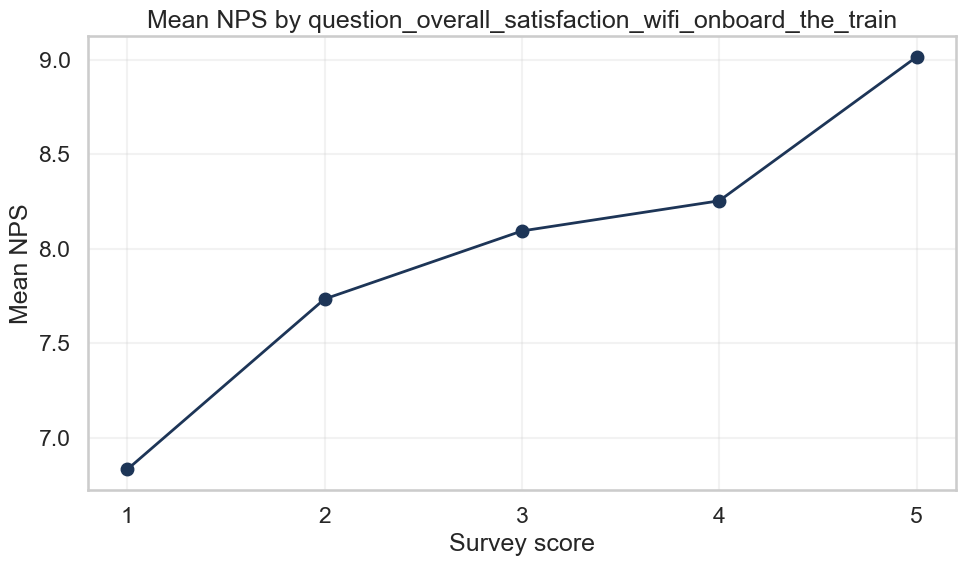

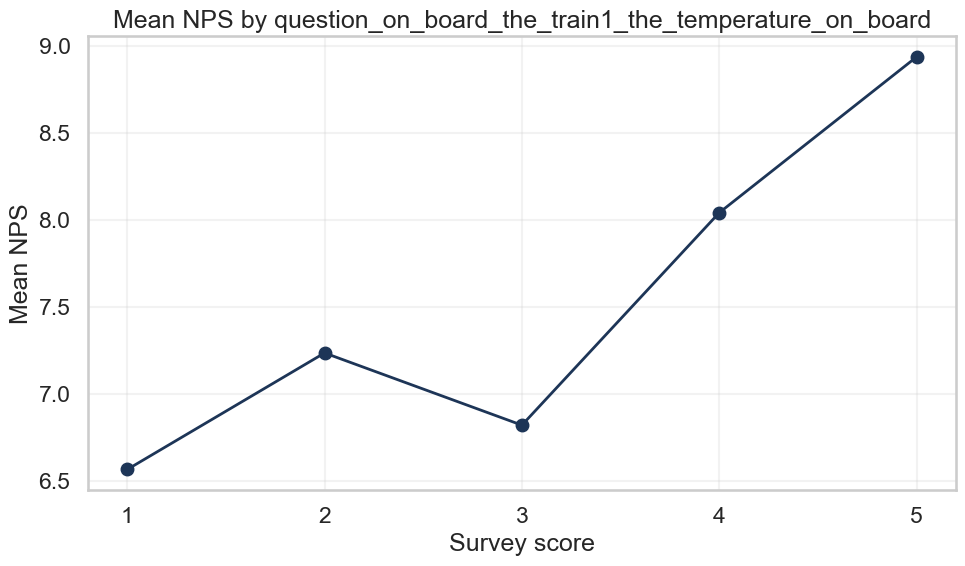

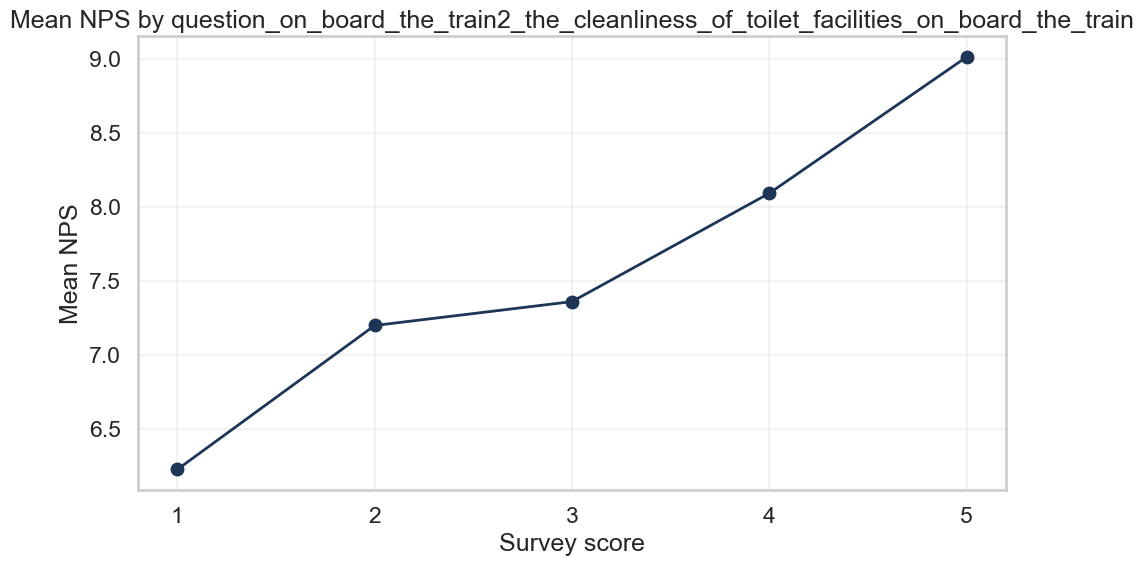

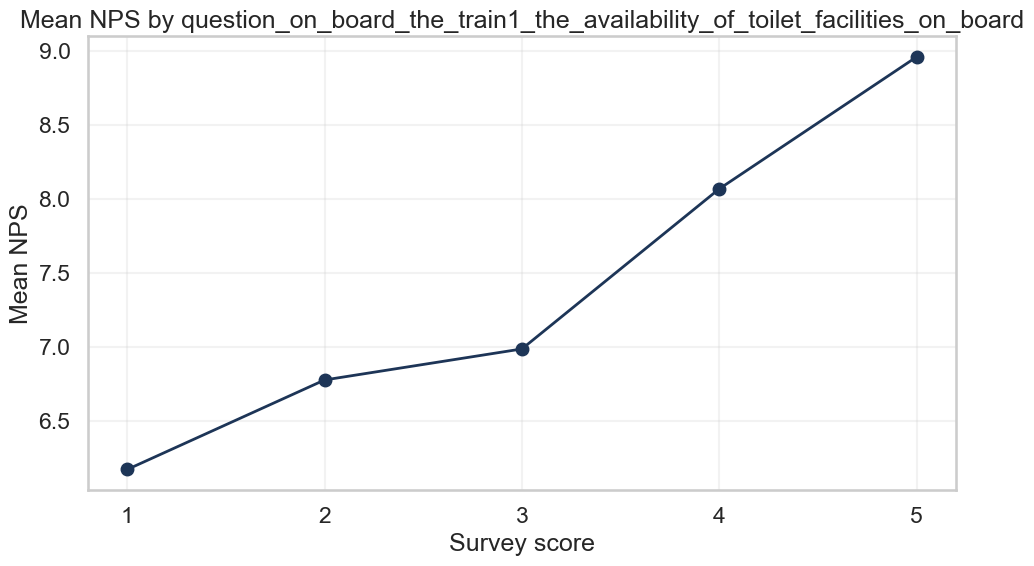

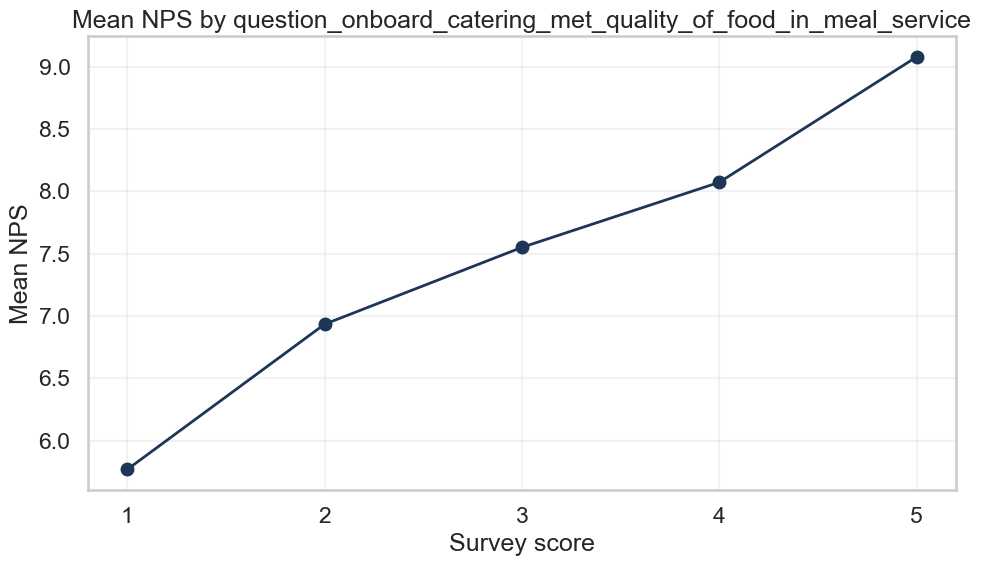

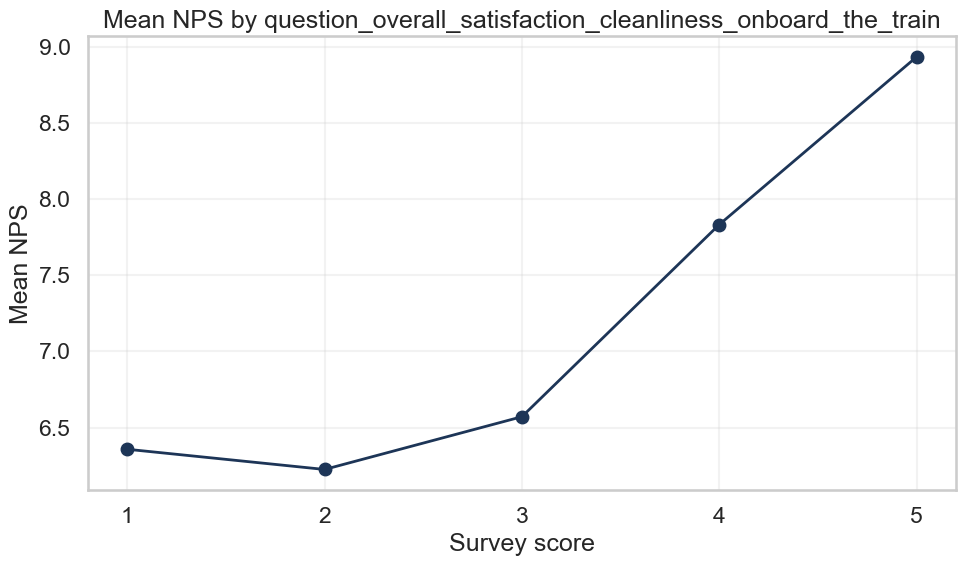

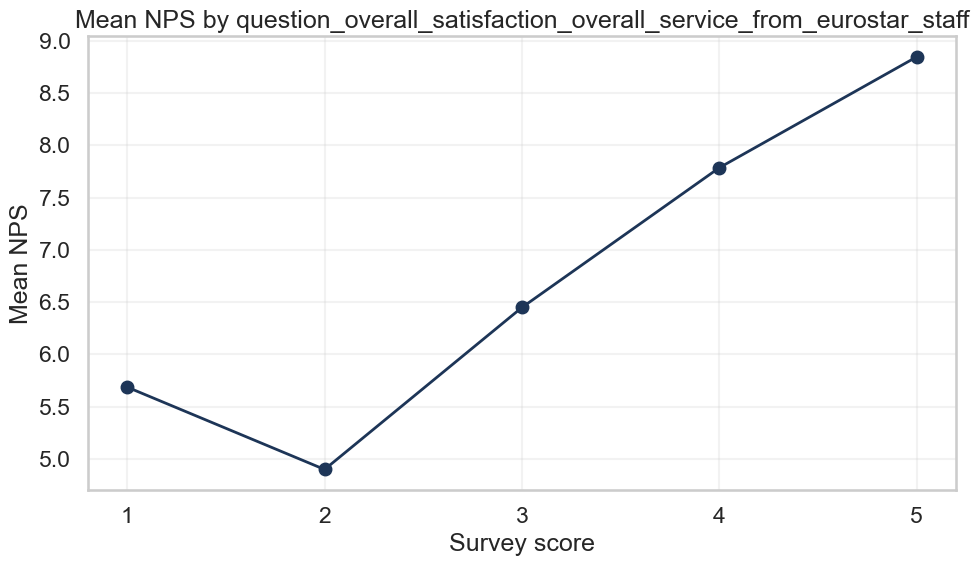

Valid observations used per survey visualization (after removing -1):


,Survey_Variable,Valid_Obs_For_Plot
0,question_overall_satisfaction_wifi_onboard_the...,178833
1,question_on_board_the_train1_the_temperature_o...,178833
2,question_on_board_the_train2_the_cleanliness_o...,178833
3,question_on_board_the_train1_the_availability_...,178833
4,question_onboard_catering_met_quality_of_food_...,178833
5,question_overall_satisfaction_cleanliness_onbo...,178833
6,question_overall_satisfaction_overall_service_...,178833


In [6]:
# SECTION 4: Survey sub-question profile plots (one figure per question)

survey_plot_table = []

for var in SURVEY_VARS:
    # Exclude sentinel -1 from descriptive visualization to avoid degenerate single-point charts.
    score = pd.to_numeric(df[var], errors='coerce')
    score = score.where(score != -1, np.nan)

    d = pd.DataFrame({
        'Survey_Score': score,
        'NPS': df[TARGET_NPS],
    }).dropna()

    if d.empty:
        d_plot = pd.DataFrame({
            'Survey_Score': ['No valid score'],
            'Mean_NPS': [df[TARGET_NPS].mean()],
            'Count': [0],
        })

        plt.figure(figsize=(10, 6))
        plt.bar(d_plot['Survey_Score'], d_plot['Mean_NPS'], color='#bdbdbd')
        plt.title(f'Mean NPS by {var} (no valid survey scores after removing -1)')
        plt.xlabel('Survey score')
        plt.ylabel('Mean NPS')
        plt.tight_layout()
        plt.show()

        survey_plot_table.append({'Survey_Variable': var, 'Valid_Obs_For_Plot': 0})
        continue

    d['Survey_Score'] = d['Survey_Score'].round().astype(int)

    d_plot = (
        d.groupby('Survey_Score', as_index=False)
        .agg(Mean_NPS=('NPS', 'mean'), Count=('NPS', 'size'))
        .sort_values('Survey_Score')
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 6))
    plt.plot(d_plot['Survey_Score'], d_plot['Mean_NPS'], marker='o', color='#1d3557', linewidth=2)
    plt.title(f'Mean NPS by {var}')
    plt.xlabel('Survey score')
    plt.ylabel('Mean NPS')
    plt.xticks(d_plot['Survey_Score'])
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    survey_plot_table.append({'Survey_Variable': var, 'Valid_Obs_For_Plot': int(len(d))})

survey_plot_table = pd.DataFrame(survey_plot_table)
print('Valid observations used per survey visualization (after removing -1):')
display(survey_plot_table)

In [7]:
# SECTION 5: Feature engineering for main thesis model

objective_numeric = [
    'total_restrictions',
    'restriction_open_Toilets',
    'restriction_open_Air Conditioning',
    'restriction_open_WiFi',
    'restriction_open_Refrigeration',
    'last_clean_score',
    'hours_since_last_clean',
]

# Build main effects with raw (non-centered) variables
base_features = [DELAY_VAR] + SURVEY_VARS + objective_numeric
equipment_feature = ['equipment_new_binary']

X_main = df[base_features + equipment_feature].copy()

# Delay x perceived service interactions (core mitigation hypothesis) using raw terms
interaction_cols = []
for s in SURVEY_VARS:
    name = f'delay_x_{s}'
    X_main[name] = df[DELAY_VAR] * df[s]
    interaction_cols.append(name)

X_main = X_main.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(float)
y_main = df[TARGET_NPS].astype(float)

# Train/validation/test split for proper model selection then final test evaluation
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_main, y_main, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)

print('Main model feature count:', X_main.shape[1])
print('Main model observations:', len(X_main))
print('Train/Val/Test:', X_train.shape, X_val.shape, X_test.shape)

Main model feature count: 23
Main model observations: 178833
Train/Val/Test: (107299, 23) (35767, 23) (35767, 23)


In [8]:
# SECTION 6: Main econometric benchmark (robust OLS, validation-first selection flow)
X_train_ols = add_constant(X_train, has_constant='add')
X_val_ols = add_constant(X_val, has_constant='add')
X_test_ols = add_constant(X_test, has_constant='add')

ols_main = OLS(y_train, X_train_ols).fit(cov_type='HC3')
ols_pred_val = ols_main.predict(X_val_ols)
ols_pred_test_trainonly = ols_main.predict(X_test_ols)

ols_val_metrics = {
    'Model': 'OLS_Main_RobustHC3',
    'Validation_R2': float(r2_score(y_val, ols_pred_val)),
    'Validation_RMSE': float(np.sqrt(mean_squared_error(y_val, ols_pred_val))),
    'Validation_MAE': float(mean_absolute_error(y_val, ols_pred_val)),
}

ols_test_metrics_trainonly = {
    'Model': 'OLS_Main_RobustHC3',
    'Test_R2': float(r2_score(y_test, ols_pred_test_trainonly)),
    'Test_RMSE': float(np.sqrt(mean_squared_error(y_test, ols_pred_test_trainonly))),
    'Test_MAE': float(mean_absolute_error(y_test, ols_pred_test_trainonly)),
}

ols_coef = pd.DataFrame({
    'Feature_Name': ols_main.params.index,
    'OLS_Coefficient': ols_main.params.values,
    'OLS_p_value': ols_main.pvalues.values,
})
ols_coef = ols_coef[ols_coef['Feature_Name'] != 'const'].copy()
ols_coef['abs_coef'] = ols_coef['OLS_Coefficient'].abs()
ols_coef = ols_coef.sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('OLS validation metrics (used for model selection):')
display(pd.DataFrame([ols_val_metrics]))
print('OLS provisional test metrics (train-only fit):')
display(pd.DataFrame([ols_test_metrics_trainonly]))
print('Top 30 OLS coefficients by absolute magnitude:')
display(ols_coef.head(30))

OLS validation metrics (used for model selection):


,Model,Validation_R2,Validation_RMSE,Validation_MAE
0,OLS_Main_RobustHC3,0.316075,1.807666,1.295916


OLS provisional test metrics (train-only fit):


,Model,Test_R2,Test_RMSE,Test_MAE
0,OLS_Main_RobustHC3,0.324785,1.793858,1.300473


Top 30 OLS coefficients by absolute magnitude:


,Feature_Name,OLS_Coefficient,OLS_p_value,abs_coef
0,question_overall_satisfaction_overall_service_...,0.627791,0.000000e+00,0.627791
1,question_onboard_catering_met_quality_of_food_...,0.400258,4.341694e-97,0.400258
2,question_overall_satisfaction_cleanliness_onbo...,0.319304,1.315672e-188,0.319304
3,question_overall_satisfaction_wifi_onboard_the...,0.231692,0.000000e+00,0.231692
4,question_on_board_the_train1_the_temperature_o...,0.156193,2.910167e-23,0.156193
5,question_on_board_the_train1_the_availability_...,0.136587,2.026593e-10,0.136587
6,equipment_new_binary,0.063234,9.837981e-06,0.063234
7,restriction_open_Toilets,0.053557,1.606930e-01,0.053557
8,total_restrictions,0.047898,2.014247e-02,0.047898
9,question_on_board_the_train2_the_cleanliness_o...,0.044712,1.424494e-02,0.044712


Fitting 3 folds for each of 12 candidates, totalling 36 fits


/Users/macpro/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/macpro/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/macpro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/macpro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/macpro/anaconda3/

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Users/macpro/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/macpro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Validation leaderboard (used to choose final model):


,Model,Validation_R2,Validation_RMSE,Validation_MAE
0,XGB_Tuned_Main,0.365589,1.741002,1.258645
1,RF_Tuned_Main,0.355418,1.754902,1.268773
2,OLS_Main_RobustHC3,0.316075,1.807666,1.295916


Final holdout test result (selected model refit on train+validation):


,Model,Test_R2,Test_RMSE,Test_MAE
0,XGB_Tuned_Main,0.370993,1.731389,1.264852


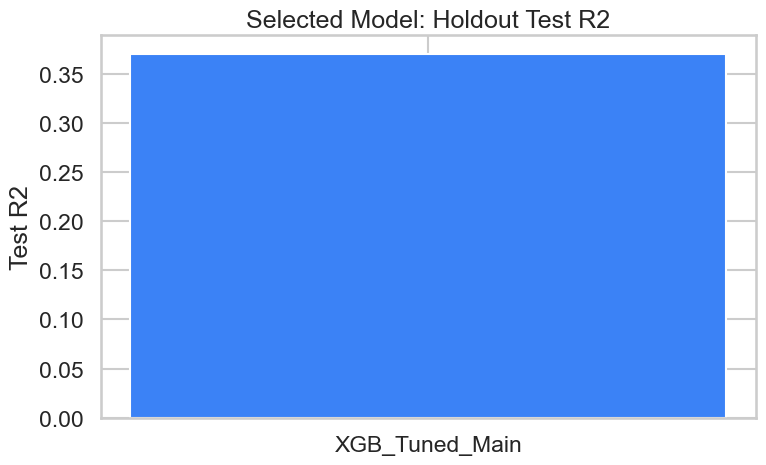

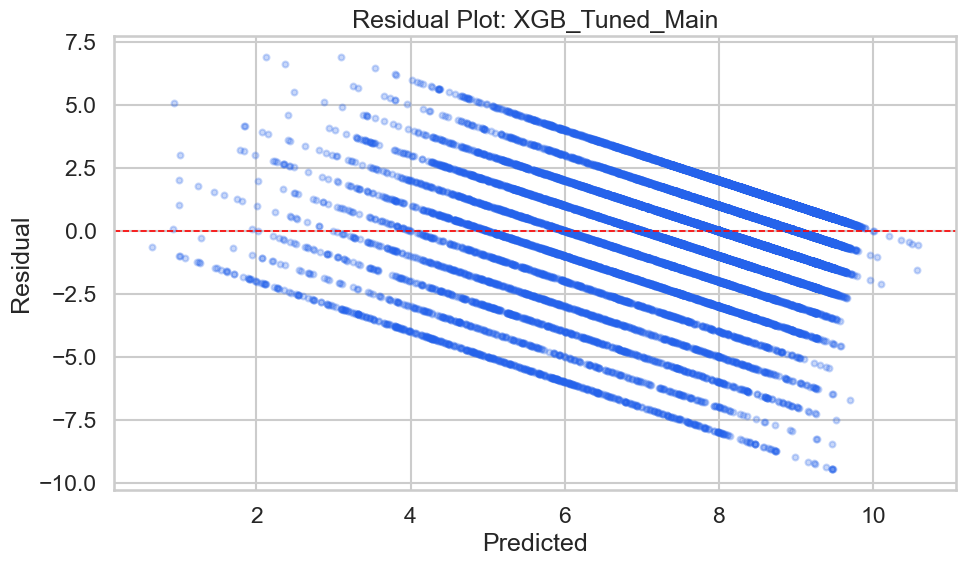

Top 30 feature importance table:


,Feature_Name,Importance
0,question_overall_satisfaction_overall_service_...,0.355971
1,question_overall_satisfaction_cleanliness_onbo...,0.133965
2,arrival_delay_minute,0.129961
3,question_overall_satisfaction_wifi_onboard_the...,0.083655
4,delay_x_question_on_board_the_train1_the_avail...,0.045439
5,question_onboard_catering_met_quality_of_food_...,0.042814
6,delay_x_question_on_board_the_train1_the_tempe...,0.027732
7,delay_x_question_overall_satisfaction_overall_...,0.020928
8,question_on_board_the_train1_the_temperature_o...,0.019472
9,delay_x_question_on_board_the_train2_the_clean...,0.019201


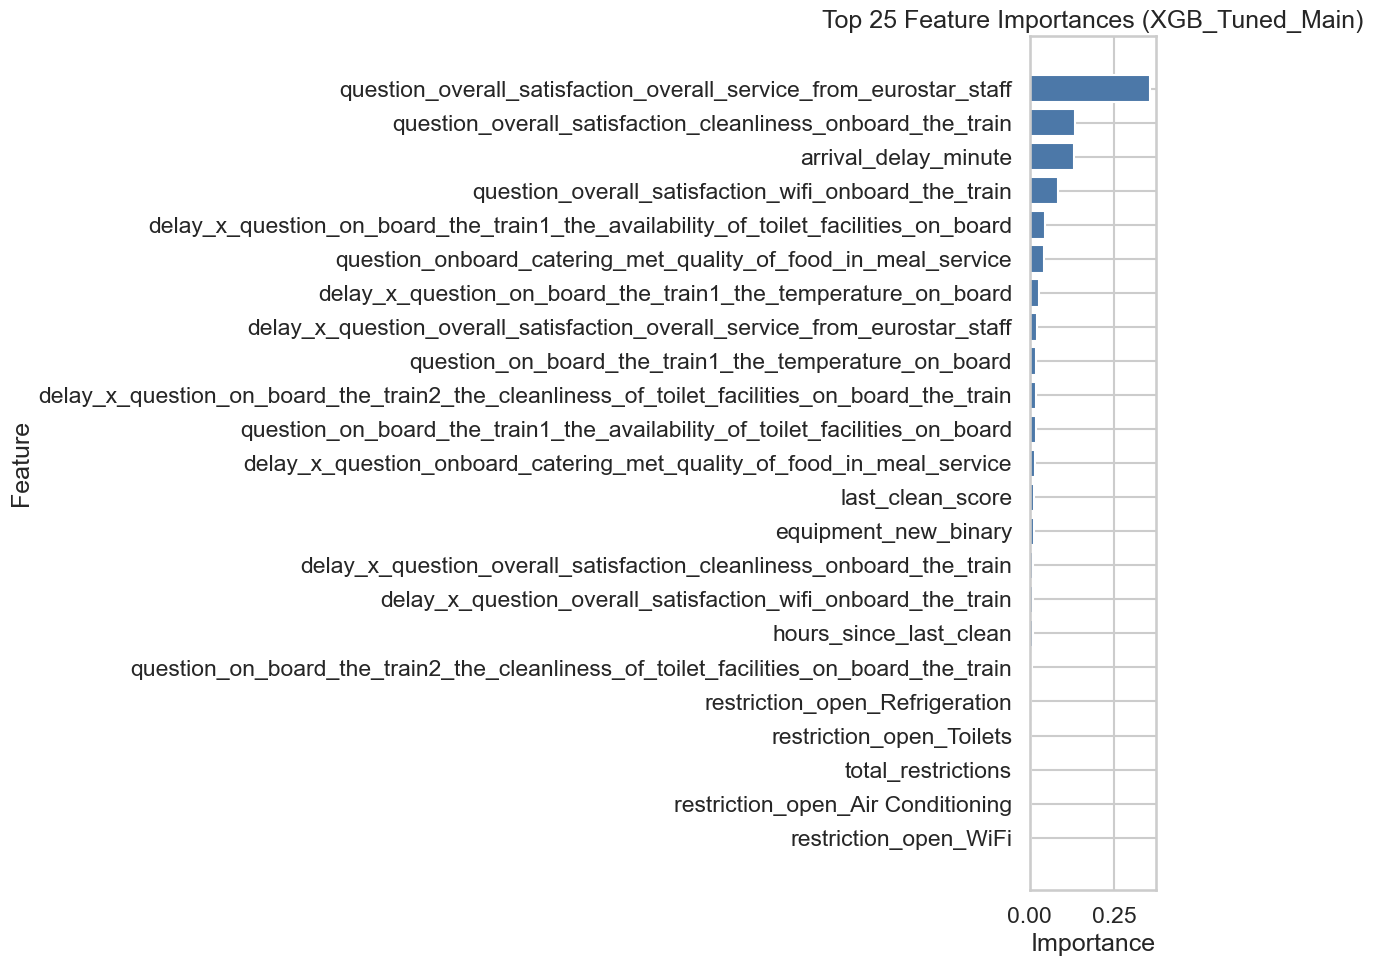

Best XGB params: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.5}
Best RF params : {'n_estimators': 700, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 12}


In [9]:
# SECTION 7-8: Tuned ML benchmark + unified comparison visuals (validation selection, test holdout)
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

xgb_param_dist = {
    'max_depth': [4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [250, 400, 600],
    'colsample_bytree': [0.5, 0.7, 0.9],
    'subsample': [0.7, 0.8, 0.9],
}

rf_param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [6, 8, 12, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [0.5, 0.7, 0.9],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=12,
    scoring='r2',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=8,
    scoring='r2',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

# Keep feature sets aligned across train/val/test and remove duplicate columns if needed
if isinstance(X_train, pd.DataFrame):
    dup_mask = X_train.columns.duplicated()
    if dup_mask.any():
        print(f"Removing {dup_mask.sum()} duplicated feature columns for ML fit.")
        keep_cols = X_train.columns[~dup_mask]
        X_train = X_train.loc[:, keep_cols].copy()
        X_val = X_val.loc[:, keep_cols].copy()
        X_test = X_test.loc[:, keep_cols].copy()
        X_train_val = X_train_val.loc[:, keep_cols].copy()

# Raise the real underlying error if anything else fails during CV
xgb_search.set_params(error_score='raise')
xgb_search.fit(X_train, y_train)
rf_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
best_rf = rf_search.best_estimator_

# Validation performance for model selection
pred_val_xgb = best_xgb.predict(X_val)
pred_val_rf = best_rf.predict(X_val)

validation_comparison_df = pd.DataFrame([
    {
        'Model': 'OLS_Main_RobustHC3',
        'Validation_R2': float(ols_val_metrics['Validation_R2']),
        'Validation_RMSE': float(ols_val_metrics['Validation_RMSE']),
        'Validation_MAE': float(ols_val_metrics['Validation_MAE']),
    },
    {
        'Model': 'XGB_Tuned_Main',
        'Validation_R2': float(r2_score(y_val, pred_val_xgb)),
        'Validation_RMSE': float(np.sqrt(mean_squared_error(y_val, pred_val_xgb))),
        'Validation_MAE': float(mean_absolute_error(y_val, pred_val_xgb)),
    },
    {
        'Model': 'RF_Tuned_Main',
        'Validation_R2': float(r2_score(y_val, pred_val_rf)),
        'Validation_RMSE': float(np.sqrt(mean_squared_error(y_val, pred_val_rf))),
        'Validation_MAE': float(mean_absolute_error(y_val, pred_val_rf)),
    },
]).sort_values('Validation_R2', ascending=False).reset_index(drop=True)

print('Validation leaderboard (used to choose final model):')
display(validation_comparison_df)

best_model_name = validation_comparison_df.iloc[0]['Model']

# Refit winning model on train+validation, then evaluate once on test set
if best_model_name == 'XGB_Tuned_Main':
    best_model = XGBRegressor(**xgb_search.best_params_, objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1)
    best_model.fit(X_train_val, y_train_val)
    best_pred = best_model.predict(X_test)
    feature_importance = pd.DataFrame({
        'Feature_Name': X_train_val.columns,
        'Importance': best_model.feature_importances_,
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
elif best_model_name == 'RF_Tuned_Main':
    best_model = RandomForestRegressor(**rf_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
    best_model.fit(X_train_val, y_train_val)
    best_pred = best_model.predict(X_test)
    feature_importance = pd.DataFrame({
        'Feature_Name': X_train_val.columns,
        'Importance': best_model.feature_importances_,
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
else:
    X_train_val_ols = add_constant(X_train_val, has_constant='add')
    X_test_ols_final = add_constant(X_test, has_constant='add')
    best_model = OLS(y_train_val, X_train_val_ols).fit(cov_type='HC3')
    best_pred = best_model.predict(X_test_ols_final)
    feature_importance = ols_coef[['Feature_Name', 'abs_coef']].rename(columns={'abs_coef': 'Importance'})

comparison_df = pd.DataFrame([
    {
        'Model': best_model_name,
        'Test_R2': float(r2_score(y_test, best_pred)),
        'Test_RMSE': float(np.sqrt(mean_squared_error(y_test, best_pred))),
        'Test_MAE': float(mean_absolute_error(y_test, best_pred)),
    },
])

print('Final holdout test result (selected model refit on train+validation):')
display(comparison_df)

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['Test_R2'], color='#3b82f6')
plt.title('Selected Model: Holdout Test R2')
plt.ylabel('Test R2')
plt.tight_layout()
plt.show()

residual_df = pd.DataFrame({
    'Predicted': best_pred,
    'Residual': y_test.values - best_pred,
})

plt.figure(figsize=(10, 6))
plt.scatter(residual_df['Predicted'], residual_df['Residual'], alpha=0.25, s=18, color='#2563eb')
plt.axhline(0, color='red', linestyle='--', linewidth=1.2)
plt.title(f'Residual Plot: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

print('Top 30 feature importance table:')
display(feature_importance.head(30))

fi_top = feature_importance.head(25).iloc[::-1]
plt.figure(figsize=(12, 10))
plt.barh(fi_top['Feature_Name'], fi_top['Importance'], color='#4c78a8')
plt.title(f'Top 25 Feature Importances ({best_model_name})')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Best XGB params:', xgb_search.best_params_)
print('Best RF params :', rf_search.best_params_)


Computing 2D PDPs for all survey variables ...
  ✓ question_overall_satisfaction_wifi_onboard_the_train
  ✓ question_on_board_the_train1_the_temperature_on_board
  ✓ question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train
  ✓ question_on_board_the_train1_the_availability_of_toilet_facilities_on_board
  ✓ question_onboard_catering_met_quality_of_food_in_meal_service
  ✓ question_overall_satisfaction_cleanliness_onboard_the_train
  ✓ question_overall_satisfaction_overall_service_from_eurostar_staff


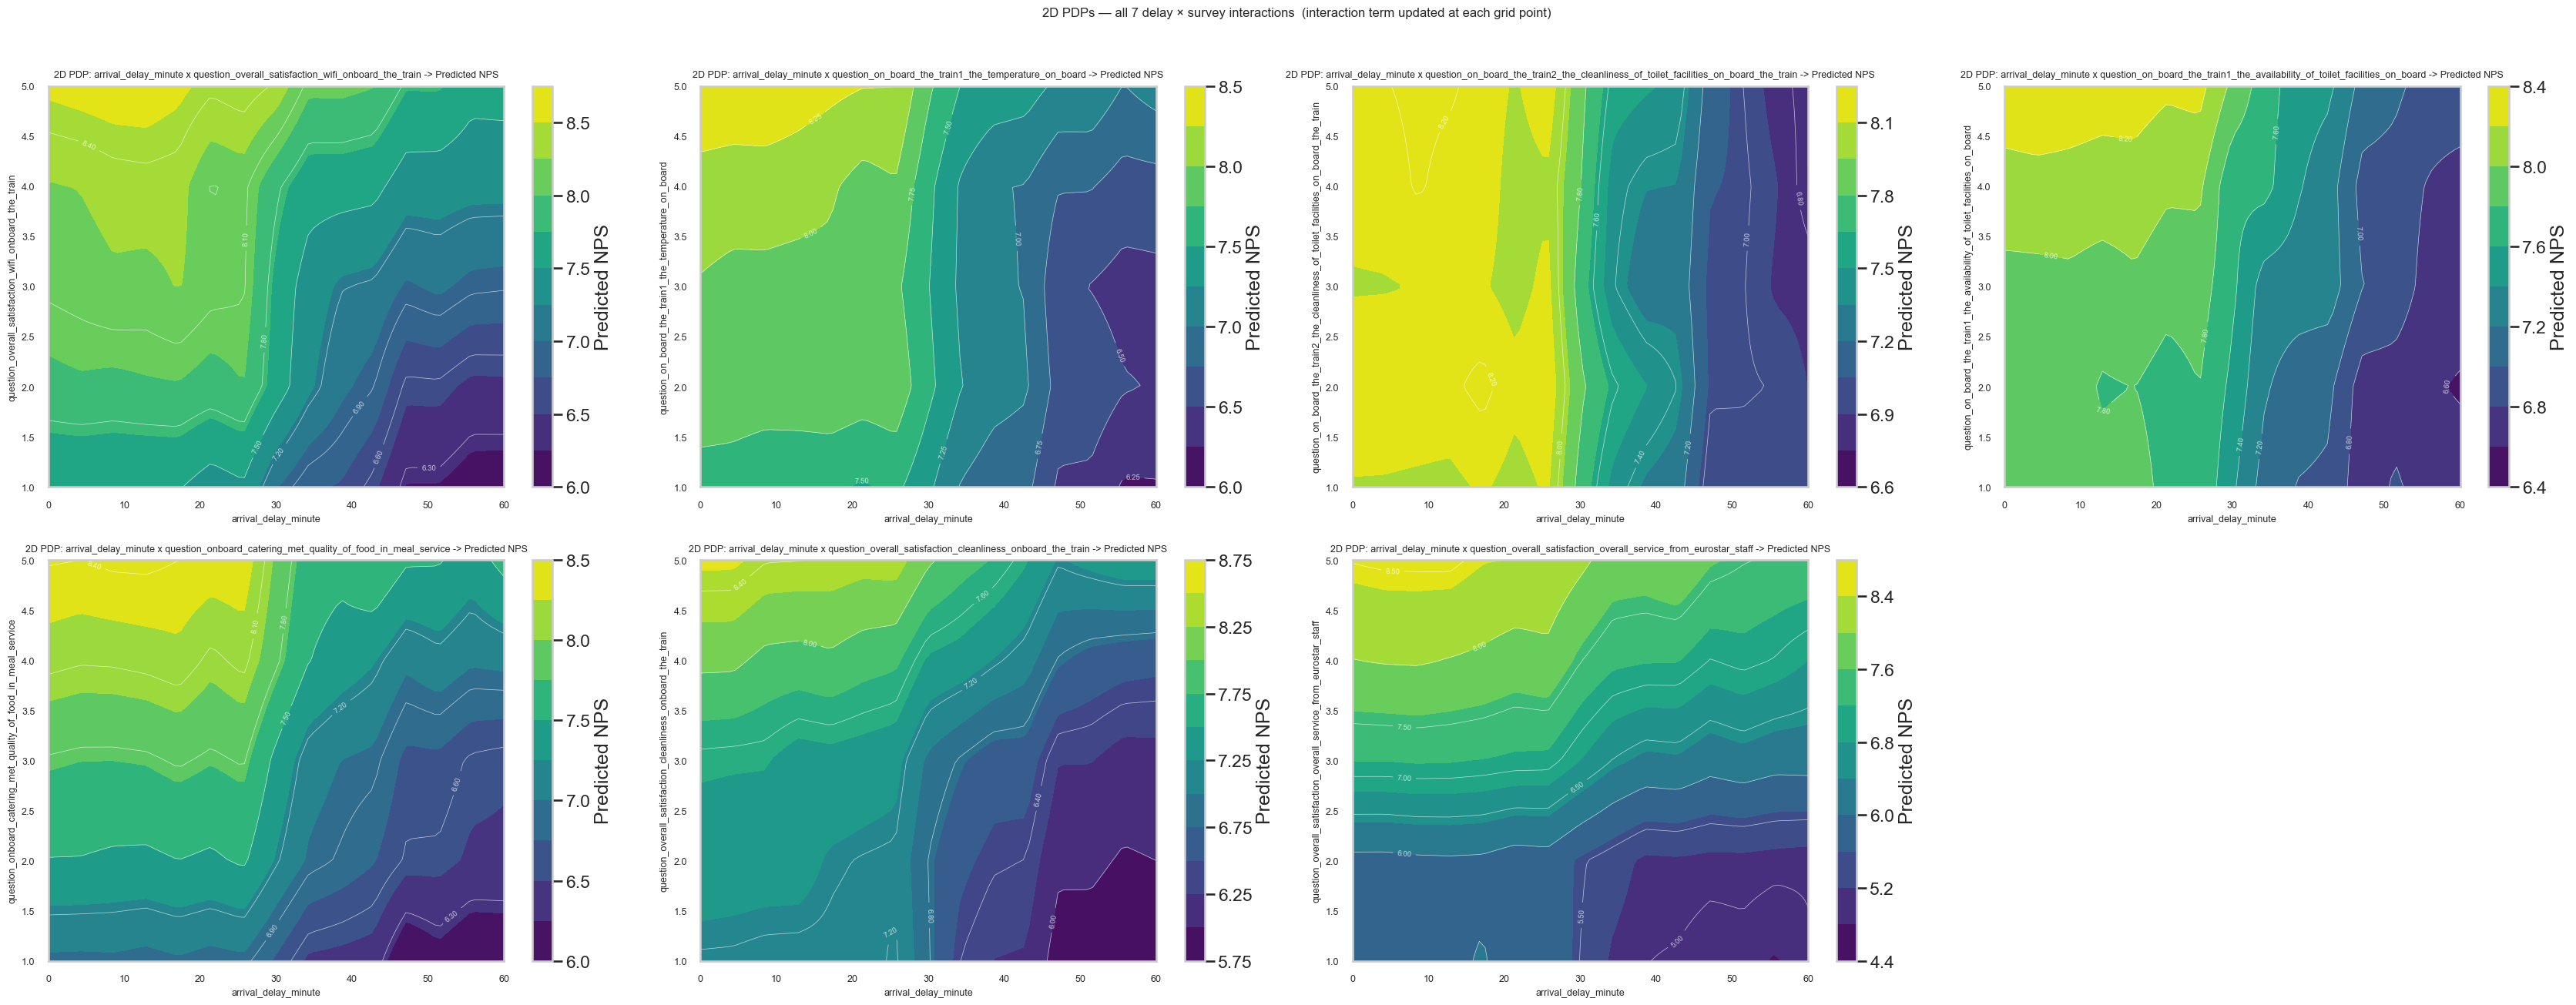

2D PDP plots displayed in Section 7-8B:


,Delay_Feature,Survey_Feature,Interaction_Feature,Grid_Delay_Pts,Grid_Survey_Pts,Background_N
0,arrival_delay_minute,question_overall_satisfaction_wifi_onboard_the...,delay_x_question_overall_satisfaction_wifi_onb...,15,5,600
1,arrival_delay_minute,question_on_board_the_train1_the_temperature_o...,delay_x_question_on_board_the_train1_the_tempe...,15,5,600
2,arrival_delay_minute,question_on_board_the_train2_the_cleanliness_o...,delay_x_question_on_board_the_train2_the_clean...,15,5,600
3,arrival_delay_minute,question_on_board_the_train1_the_availability_...,delay_x_question_on_board_the_train1_the_avail...,15,5,600
4,arrival_delay_minute,question_onboard_catering_met_quality_of_food_...,delay_x_question_onboard_catering_met_quality_...,15,5,600
5,arrival_delay_minute,question_overall_satisfaction_cleanliness_onbo...,delay_x_question_overall_satisfaction_cleanlin...,15,5,600
6,arrival_delay_minute,question_overall_satisfaction_overall_service_...,delay_x_question_overall_satisfaction_overall_...,15,5,600


In [10]:
# SECTION 7-8B: 2D PDPs — all 7 delay × survey interactions (vectorised, interaction-corrected)
# Key fix: delay_x_survey column is updated at each grid point so the model
# sees consistent inputs (no contradictory delay vs interaction values).

import math
import warnings; warnings.filterwarnings('ignore')
from scipy.interpolate import RegularGridInterpolator

if 'best_model' not in dir() or 'X_test' not in dir():
    raise RuntimeError('Run Section 7-8 first to fit best_model and create X_test.')

# ── Grid & background ─────────────────────────────────────────────────────────
DELAY_COL   = DELAY_VAR
delay_grid  = np.linspace(0, 60, 15)              # 15 points, 0–60 min
survey_grid = np.array([1, 2, 3, 4, 5], dtype=float)  # full 1–5 scale
N_BG        = 600                                  # background sample

X_bg = X_test.sample(min(N_BG, len(X_test)), random_state=RANDOM_STATE).reset_index(drop=True)

# ── Vectorised PDP computation (one predict call per variable) ─────────────────
# For each (survey_val, delay_val) grid point we copy the background dataset,
# set delay, survey AND delay_x_survey = delay*survey, then average predictions.
print('Computing 2D PDPs for all survey variables ...')
pdp_grids = {}

for sv in SURVEY_VARS:
    inter_col = f'delay_x_{sv}'
    chunks = []
    for s_val in survey_grid:
        for d_val in delay_grid:
            X_mod            = X_bg.copy()
            X_mod[DELAY_COL] = d_val
            X_mod[sv]        = s_val
            if inter_col in X_mod.columns:
                X_mod[inter_col] = d_val * s_val   # interaction consistent with sweep
            chunks.append(X_mod)

    preds = best_model.predict(pd.concat(chunks, ignore_index=True))
    # reshape → (n_survey=5, n_delay=15, n_bg=600), mean over background
    grid = preds.reshape(len(survey_grid), len(delay_grid), len(X_bg)).mean(axis=2)
    pdp_grids[sv] = grid
    print(f'  ✓ {sv}')

# ── Plot — same title / axis format as original Section 7-8B ─────────────────
ncols     = 4
nrows     = math.ceil(len(SURVEY_VARS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 8.5, nrows * 6.5))
axes_flat = axes.flatten()

for idx, sv in enumerate(SURVEY_VARS):
    ax   = axes_flat[idx]
    grid = pdp_grids[sv]

    # Interpolate raw 5×15 grid → 80×80 for smooth contours
    interp = RegularGridInterpolator(
        (survey_grid, delay_grid), grid, method='linear',
        bounds_error=False, fill_value=None,
    )
    s_fine = np.linspace(1, 5, 80)
    d_fine = np.linspace(0, 60, 80)
    SM, DM = np.meshgrid(s_fine, d_fine, indexing='ij')
    Z = interp(np.column_stack([SM.ravel(), DM.ravel()])).reshape(SM.shape)

    cf = ax.contourf(d_fine, s_fine, Z, levels=10, cmap='viridis')
    cs = ax.contour( d_fine, s_fine, Z, levels=8, colors='white', linewidths=0.5, alpha=0.7)
    ax.clabel(cs, fmt='%.2f', fontsize=7, inline=True)
    fig.colorbar(cf, ax=ax, label='Predicted NPS')

    ax.set_title(
        f'2D PDP: {DELAY_COL} x {sv} -> Predicted NPS',
        fontsize=9, pad=8,
    )
    ax.set_xlabel(DELAY_COL, fontsize=9)
    ax.set_ylabel(sv, fontsize=9)
    ax.tick_params(axis='both', labelsize=9)

for idx in range(len(SURVEY_VARS), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle(
    f'2D PDPs — all {len(SURVEY_VARS)} delay × survey interactions  '
    '(interaction term updated at each grid point)',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

pdp_pairs_used_df = pd.DataFrame([
    {
        'Delay_Feature':       DELAY_COL,
        'Survey_Feature':      sv,
        'Interaction_Feature': f'delay_x_{sv}',
        'Grid_Delay_Pts':      len(delay_grid),
        'Grid_Survey_Pts':     len(survey_grid),
        'Background_N':        N_BG,
    }
    for sv in SURVEY_VARS
])
print('2D PDP plots displayed in Section 7-8B:')
display(pdp_pairs_used_df)


In [11]:
# SECTION 8 (Deprecated duplicate cell)
# This cell is intentionally kept as a no-op to preserve notebook structure.
print('Duplicate comparison cell skipped. Main benchmark and visuals are in the previous section.')

Duplicate comparison cell skipped. Main benchmark and visuals are in the previous section.


Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Users/macpro/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/macpro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


10A Objective-only model comparison:


,Model,Rows,Test_R2,Test_RMSE,Test_MAE
0,ObjectiveOnly_XGB_Tuned,178833,0.111331,2.057960,1.528448
1,ObjectiveOnly_RF,178833,0.110700,2.058690,1.530231
2,ObjectiveOnly_OLS,178833,0.095036,2.076742,1.536089


10A OLS table (top by significance):


,Feature_Name,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
0,const,8.145732,0.011321,719.555119,0.000000e+00,8.123544,8.167919
1,arrival_delay_minute,-0.022554,0.000368,-61.294247,0.000000e+00,-0.023275,-0.021833
2,last_clean_score,0.003376,0.000188,17.998964,1.984961e-72,0.003008,0.003743
3,hours_since_last_clean,-0.000090,0.000027,-3.396905,6.815252e-04,-0.000142,-0.000038
4,total_restrictions,0.065275,0.020844,3.131628,1.738397e-03,0.024422,0.106128
5,restriction_open_Air Conditioning,-0.043516,0.023687,-1.837135,6.619004e-02,-0.089941,0.002909
6,restriction_open_WiFi,0.109111,0.076476,1.426728,1.536584e-01,-0.040780,0.259002
7,equipment_new_binary,0.017372,0.014132,1.229304,2.189579e-01,-0.010326,0.045070
8,restriction_open_Refrigeration,0.006767,0.035823,0.188901,8.501702e-01,-0.063445,0.076980
9,restriction_open_Toilets,-0.007087,0.039476,-0.179535,8.575177e-01,-0.084458,0.070283


10A XGB feature table (top 25):


,Feature_Name,XGB_Importance
0,arrival_delay_minute,0.635628
1,last_clean_score,0.084867
2,equipment_new_binary,0.078127
3,hours_since_last_clean,0.073697
4,total_restrictions,0.028158
5,restriction_open_Air Conditioning,0.027828
6,restriction_open_Refrigeration,0.027651
7,restriction_open_Toilets,0.022903
8,restriction_open_WiFi,0.021141


10A RF feature table (top 25):


,Feature_Name,RF_Importance
0,arrival_delay_minute,0.816731
1,hours_since_last_clean,0.078089
2,last_clean_score,0.070263
3,equipment_new_binary,0.013162
4,total_restrictions,0.007875
5,restriction_open_Air Conditioning,0.004862
6,restriction_open_Refrigeration,0.004485
7,restriction_open_Toilets,0.003446
8,restriction_open_WiFi,0.001086


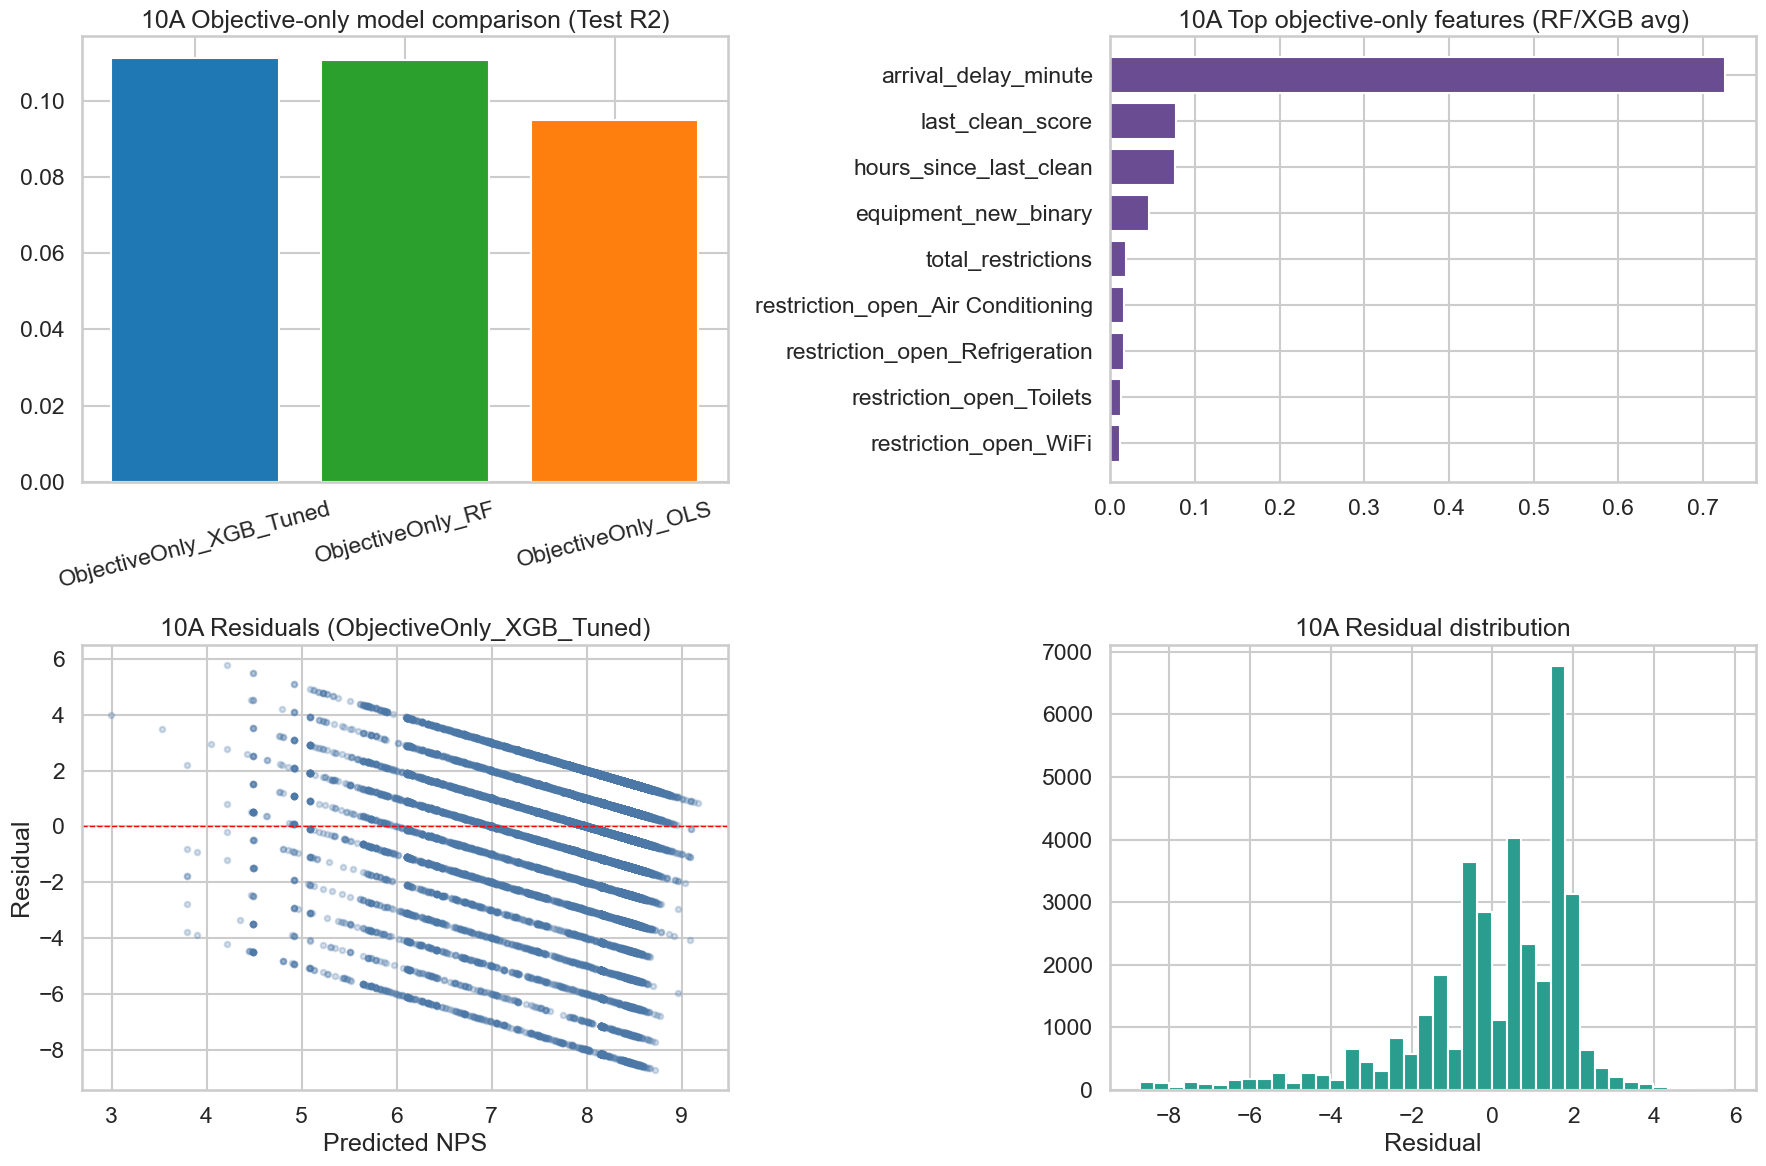

10A 2D PDP plots are disabled for this run.


In [12]:
# SECTION 10A: Mechanism robustness (objective-only, no survey variables)
robust_rows = []

# Objective-only design matrix with binary train generation indicator
objective_only_base = [DELAY_VAR] + objective_numeric + ['equipment_new_binary']
X_obj_only = df[objective_only_base].copy()
X_obj_only = X_obj_only.apply(pd.to_numeric, errors='coerce').fillna(0.0).astype(float)
y_obj_only = df[TARGET_NPS].astype(float)

Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(
    X_obj_only, y_obj_only, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# OLS objective-only
Xo_tr_ols = add_constant(Xo_tr, has_constant='add')
Xo_te_ols = add_constant(Xo_te, has_constant='add')
ols_obj = OLS(yo_tr, Xo_tr_ols).fit(cov_type='HC3')
pred_obj_ols = ols_obj.predict(Xo_te_ols)

objective_only_ols_table_df = (
    ols_obj.summary2().tables[1]
    .reset_index()
    .rename(columns={'index': 'Feature_Name'})
    .sort_values('P>|z|')
    .reset_index(drop=True)
)

# RF objective-only
rf_obj = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_obj.fit(Xo_tr, yo_tr)
pred_obj_rf = rf_obj.predict(Xo_te)

# XGB objective-only with tuning
xgb_obj_base = XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1)
xgb_obj_param_dist = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [250, 400, 600],
    'colsample_bytree': [0.5, 0.7, 0.9],
    'subsample': [0.7, 0.8, 0.9],
}
xgb_obj_search = RandomizedSearchCV(
    estimator=xgb_obj_base,
    param_distributions=xgb_obj_param_dist,
    n_iter=8,
    scoring='r2',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
xgb_obj_search.fit(Xo_tr, yo_tr)
best_xgb_obj = xgb_obj_search.best_estimator_
pred_obj_xgb = best_xgb_obj.predict(Xo_te)

objective_only_model_comparison_df = pd.DataFrame([
    {
        'Model': 'ObjectiveOnly_OLS',
        'Rows': int(len(X_obj_only)),
        'Test_R2': float(r2_score(yo_te, pred_obj_ols)),
        'Test_RMSE': float(np.sqrt(mean_squared_error(yo_te, pred_obj_ols))),
        'Test_MAE': float(mean_absolute_error(yo_te, pred_obj_ols)),
    },
    {
        'Model': 'ObjectiveOnly_RF',
        'Rows': int(len(X_obj_only)),
        'Test_R2': float(r2_score(yo_te, pred_obj_rf)),
        'Test_RMSE': float(np.sqrt(mean_squared_error(yo_te, pred_obj_rf))),
        'Test_MAE': float(mean_absolute_error(yo_te, pred_obj_rf)),
    },
    {
        'Model': 'ObjectiveOnly_XGB_Tuned',
        'Rows': int(len(X_obj_only)),
        'Test_R2': float(r2_score(yo_te, pred_obj_xgb)),
        'Test_RMSE': float(np.sqrt(mean_squared_error(yo_te, pred_obj_xgb))),
        'Test_MAE': float(mean_absolute_error(yo_te, pred_obj_xgb)),
    },
]).sort_values('Test_R2', ascending=False).reset_index(drop=True)

# XGB/RF result tables
objective_only_xgb_table_df = pd.DataFrame({
    'Feature_Name': Xo_tr.columns,
    'XGB_Importance': best_xgb_obj.feature_importances_,
}).sort_values('XGB_Importance', ascending=False).reset_index(drop=True)

objective_only_rf_table_df = pd.DataFrame({
    'Feature_Name': Xo_tr.columns,
    'RF_Importance': rf_obj.feature_importances_,
}).sort_values('RF_Importance', ascending=False).reset_index(drop=True)

objective_only_feature_importance_df = objective_only_xgb_table_df.merge(
    objective_only_rf_table_df,
    on='Feature_Name',
    how='outer',
)
objective_only_feature_importance_df['Importance_Avg'] = objective_only_feature_importance_df[['XGB_Importance', 'RF_Importance']].mean(axis=1)
objective_only_feature_importance_df = objective_only_feature_importance_df.sort_values('Importance_Avg', ascending=False).reset_index(drop=True)

print('10A Objective-only model comparison:')
display(objective_only_model_comparison_df)
print('10A OLS table (top by significance):')
display(objective_only_ols_table_df.head(40))
print('10A XGB feature table (top 25):')
display(objective_only_xgb_table_df.head(25))
print('10A RF feature table (top 25):')
display(objective_only_rf_table_df.head(25))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].bar(objective_only_model_comparison_df['Model'], objective_only_model_comparison_df['Test_R2'], color=['#1f77b4', '#2ca02c', '#ff7f0e'])
axes[0, 0].set_title('10A Objective-only model comparison (Test R2)')
axes[0, 0].tick_params(axis='x', rotation=15)

top_obj_imp = objective_only_feature_importance_df.head(20).iloc[::-1]
axes[0, 1].barh(top_obj_imp['Feature_Name'], top_obj_imp['Importance_Avg'], color='#6a4c93')
axes[0, 1].set_title('10A Top objective-only features (RF/XGB avg)')

best_obj_name = objective_only_model_comparison_df.iloc[0]['Model']
if best_obj_name == 'ObjectiveOnly_XGB_Tuned':
    best_obj_pred = pred_obj_xgb
elif best_obj_name == 'ObjectiveOnly_RF':
    best_obj_pred = pred_obj_rf
else:
    best_obj_pred = pred_obj_ols

obj_res_df = pd.DataFrame({'Predicted': best_obj_pred, 'Residual': yo_te.values - best_obj_pred})
axes[1, 0].scatter(obj_res_df['Predicted'], obj_res_df['Residual'], alpha=0.25, s=16, color='#4c78a8')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title(f'10A Residuals ({best_obj_name})')
axes[1, 0].set_xlabel('Predicted NPS')
axes[1, 0].set_ylabel('Residual')

axes[1, 1].hist(obj_res_df['Residual'], bins=40, color='#2a9d8f', edgecolor='white')
axes[1, 1].set_title('10A Residual distribution')
axes[1, 1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

# 2D PDPs removed for this run
objective_2d_pdp_pairs_df = pd.DataFrame(columns=['Feature_1', 'Feature_2'])
print('10A 2D PDP plots are disabled for this run.')

for _, r in objective_only_model_comparison_df.iterrows():
    robust_rows.append({
        'Robustness_Model': r['Model'],
        'Rows': int(r['Rows']),
        'Test_R2': float(r['Test_R2']),
        'Test_RMSE': float(r['Test_RMSE']),
    })

scipy 1.17.1  shap 0.51.0 OK
numpy 1.26.4  |  shap 0.51.0  — all OK


Model: XGB_Tuned_Main
Mean |SHAP| — top 20 features:


,Feature,Mean_Abs_SHAP
0,question_overall_satisfaction_overall_service_...,0.505094
1,question_overall_satisfaction_cleanliness_onbo...,0.337844
2,question_overall_satisfaction_wifi_onboard_the...,0.204085
3,arrival_delay_minute,0.170324
4,last_clean_score,0.073241
5,question_onboard_catering_met_quality_of_food_...,0.064630
6,delay_x_question_on_board_the_train1_the_avail...,0.050286
7,question_on_board_the_train1_the_temperature_o...,0.041700
8,delay_x_question_overall_satisfaction_cleanlin...,0.038537
9,delay_x_question_on_board_the_train1_the_tempe...,0.034240


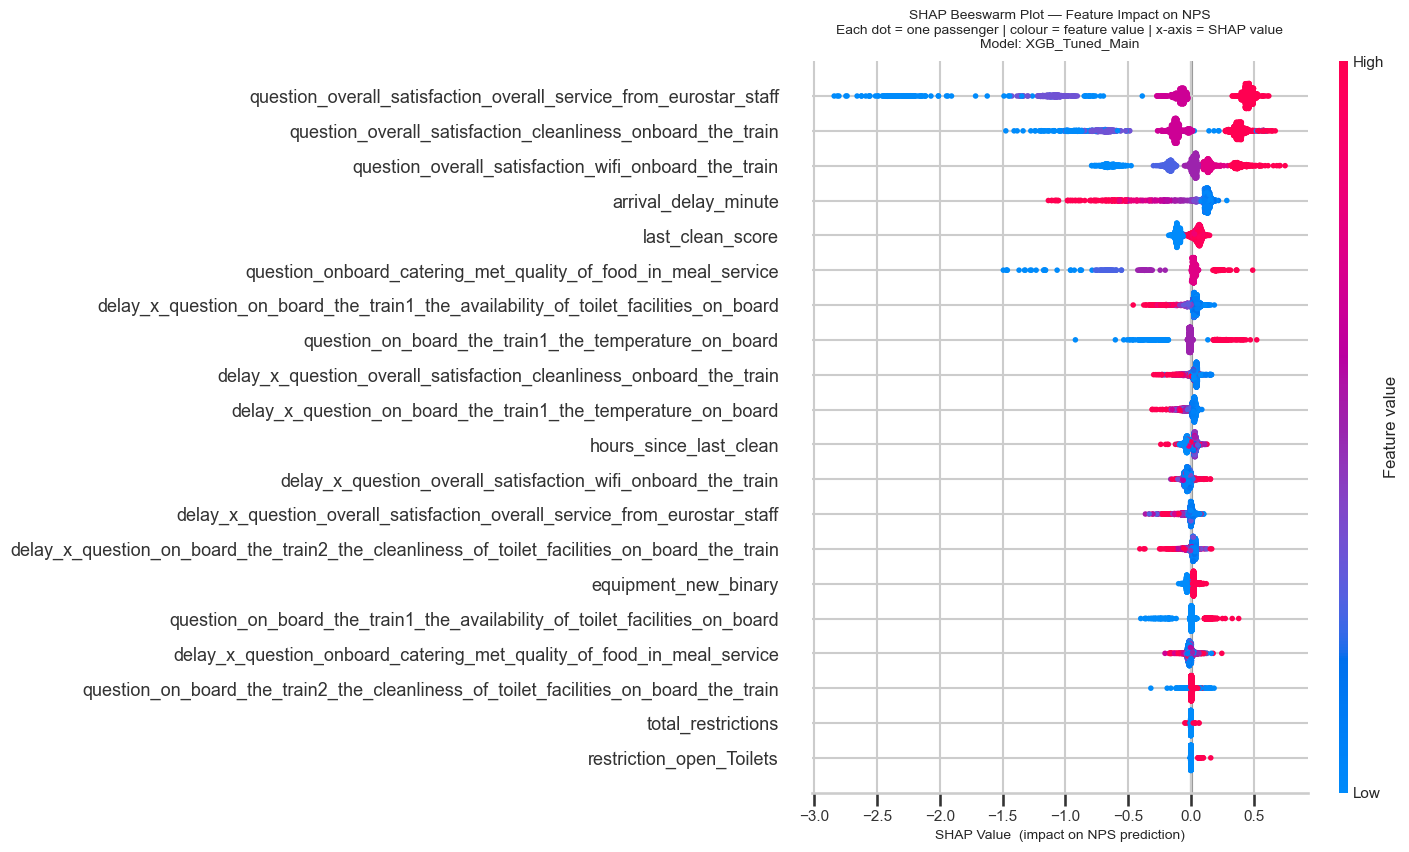

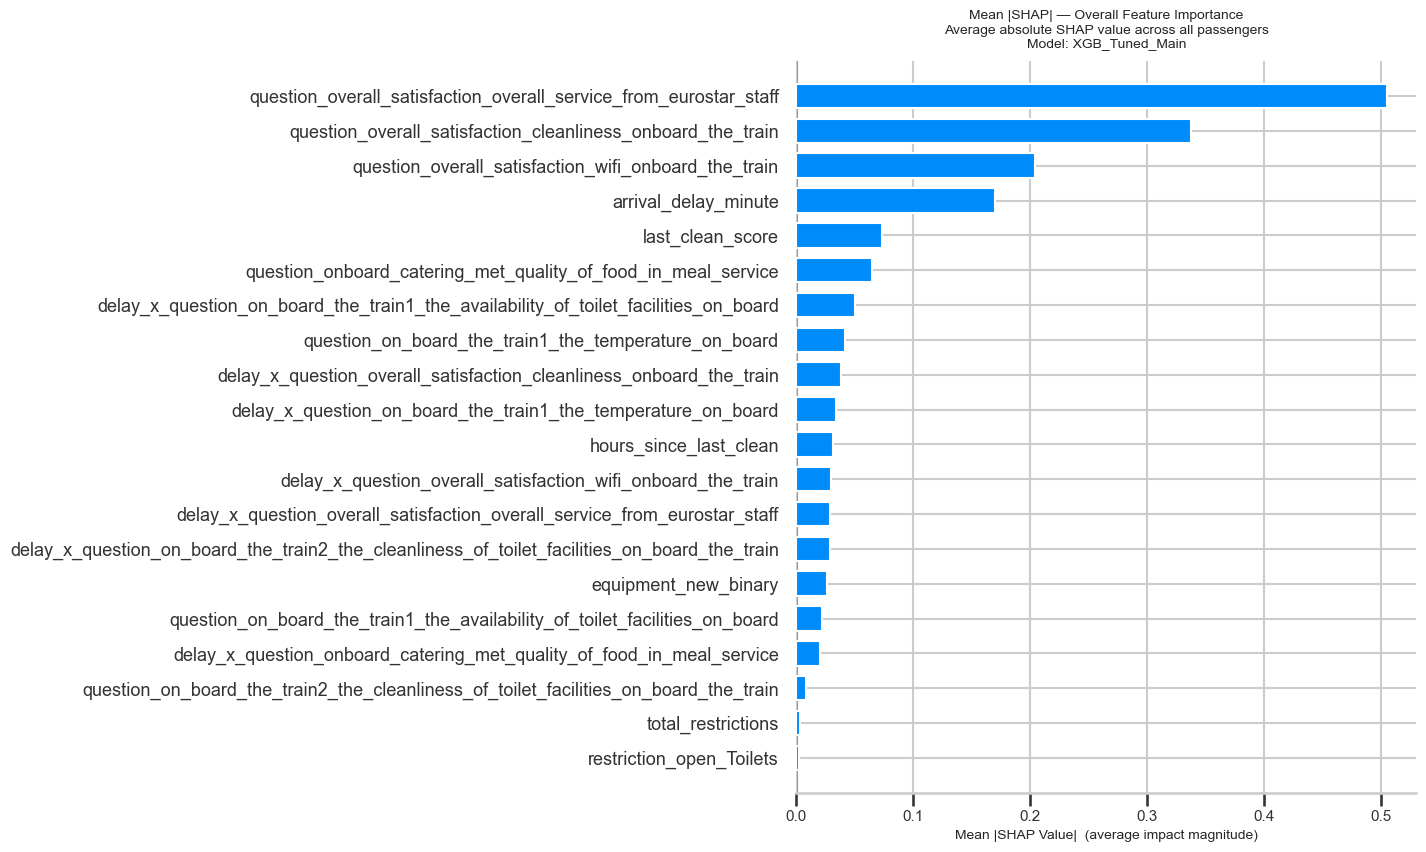

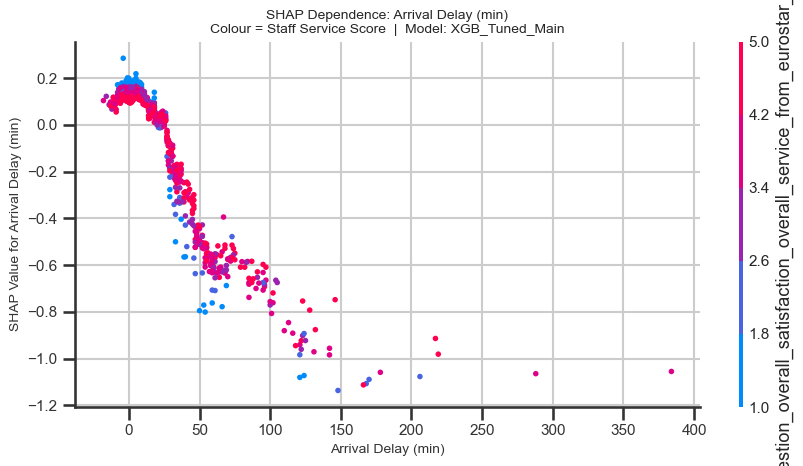

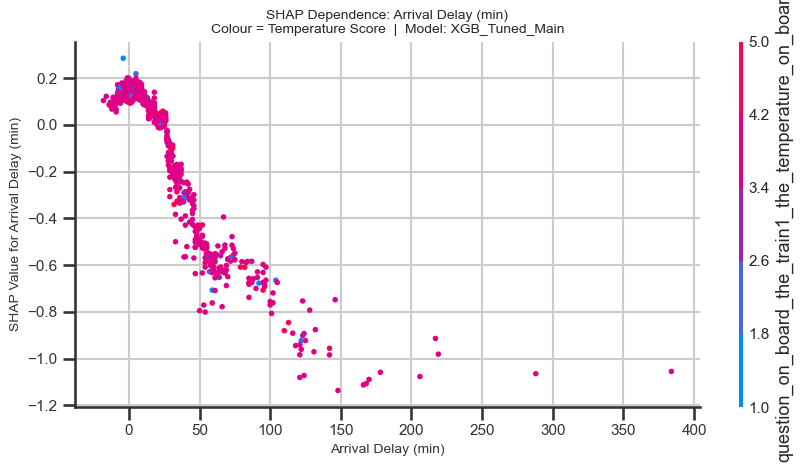


Moderation SHAP | zero-delay n=391  high-delay n=685
  Buffering   = service matters MORE when delayed (SHAP gap widens)
  Compounding = service matters LESS when delayed (SHAP gap narrows)


,Survey Variable,SHAP Gap (Zero Delay),SHAP Gap (High Delay),Moderation (High-Zero),Mean SHAP (Individual),Role under Delay
0,Staff Service,0.9355,1.1791,0.2436,-0.0208,Buffering
1,Temperature,0.2876,0.3571,0.0695,-0.0013,Buffering
2,Train Cleanliness,0.8269,0.8853,0.0585,-0.0105,Buffering
3,WiFi,0.4588,0.5014,0.0426,-0.0050,Buffering
4,Toilet Clean.,-0.0051,0.0072,0.0122,0.0034,Buffering
5,Toilet Avail.,0.2475,0.2439,-0.0036,0.0036,Compounding
6,Catering,0.8197,0.5794,-0.2403,-0.0011,Compounding


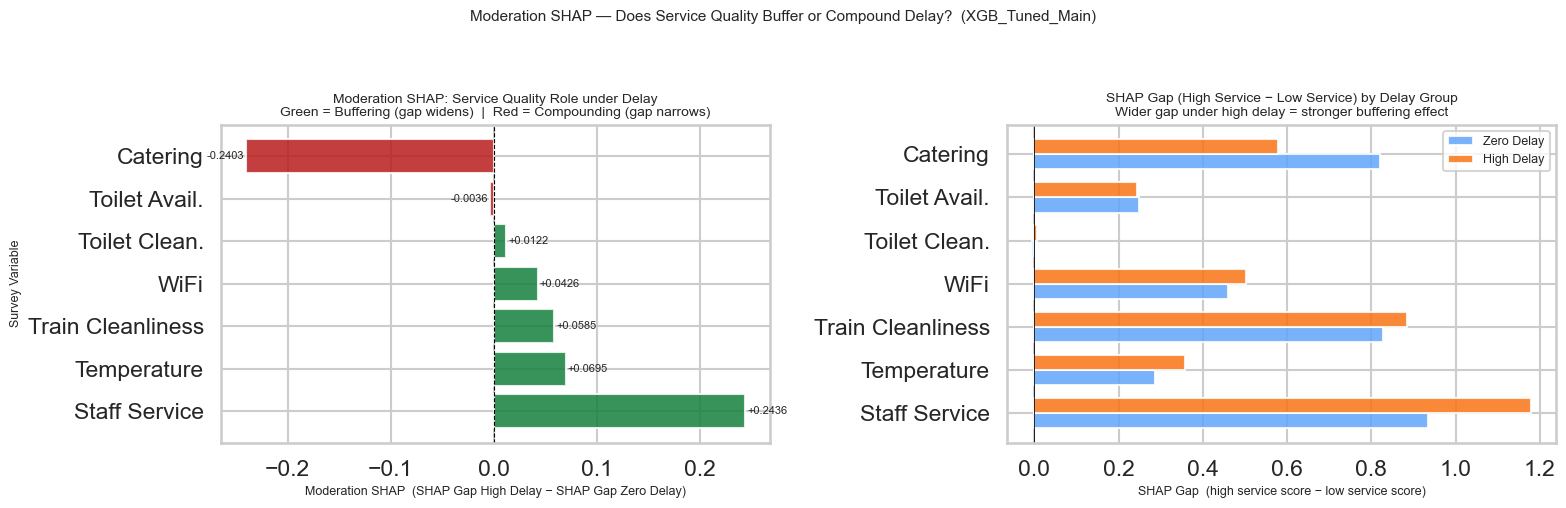

In [48]:
# SECTION 12: SHAP Analysis — Feature Attribution and Delay Moderation

import importlib.util, subprocess, sys, warnings
warnings.filterwarnings('ignore')

import scipy
print(f'scipy {scipy.__version__}', end='  ')

try:
    import shap as _shap_test
    print(f'shap {_shap_test.__version__} OK')
    _shap_needs_fix = False
except Exception as _e:
    _shap_needs_fix = True

if _shap_needs_fix:
    import numpy as _np_chk
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy<2', '-q'])
    raise SystemExit('NumPy downgraded. Restart kernel.')

import shap, importlib
importlib.invalidate_caches()
import numpy as np
print(f'numpy {np.__version__}  |  shap {shap.__version__}  — all OK')

shap.initjs()

if 'X_test' not in dir():
    raise RuntimeError('Run Section 7-8 first.')

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor as _XGB

if 'best_model' in dir() and isinstance(best_model, (_XGB, RandomForestRegressor)):
    shap_model, shap_model_label = best_model, best_model_name
elif 'best_xgb' in dir():
    shap_model, shap_model_label = best_xgb, 'XGB_Tuned_Main (CV estimator)'
else:
    raise RuntimeError('No tree model found.')

print(f'Model: {shap_model_label}')

# ── 1. SHAP values ────────────────────────────────────────────────────────────
N_SHAP = 2000
X_shap = X_test.sample(min(N_SHAP, len(X_test)), random_state=RANDOM_STATE).reset_index(drop=True)

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)
shap_df     = pd.DataFrame(shap_values, columns=X_shap.columns)

mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False).reset_index()
mean_abs_shap.columns = ['Feature', 'Mean_Abs_SHAP']
print('Mean |SHAP| — top 20 features:')
display(mean_abs_shap.head(20))

# ── 2. Beeswarm — feature impact direction and magnitude ──────────────────────
fig_beeswarm, ax_beeswarm = plt.subplots(figsize=(10, 8))
plt.sca(ax_beeswarm)
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
ax_beeswarm.set_title(f'SHAP Beeswarm Plot — Feature Impact on NPS\n'
                      f'Each dot = one passenger | colour = feature value | x-axis = SHAP value\n'
                      f'Model: {shap_model_label}', fontsize=10, pad=10)
ax_beeswarm.set_xlabel('SHAP Value  (impact on NPS prediction)', fontsize=10)
plt.tight_layout()
plt.show()

# ── 3. Bar chart — mean absolute SHAP ─────────────────────────────────────────
fig_bar, ax_bar = plt.subplots(figsize=(10, 7))
plt.sca(ax_bar)
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=20, show=False)
ax_bar.set_title(f'Mean |SHAP| — Overall Feature Importance\n'
                 f'Average absolute SHAP value across all passengers\n'
                 f'Model: {shap_model_label}', fontsize=10, pad=10)
ax_bar.set_xlabel('Mean |SHAP Value|  (average impact magnitude)', fontsize=10)
plt.tight_layout()
plt.show()

# ── 4. Dependence plots ───────────────────────────────────────────────────────
staff_col = 'question_overall_satisfaction_overall_service_from_eurostar_staff'
temp_col  = 'question_on_board_the_train1_the_temperature_on_board'

dep_configs = [
    (DELAY_VAR, staff_col, 'Arrival Delay (min)', 'Staff Service Score'),
    (DELAY_VAR, temp_col,  'Arrival Delay (min)', 'Temperature Score'),
]
for feat, color_feat, xlabel, color_label in dep_configs:
    if color_feat not in X_shap.columns:
        continue
    fig_dep, ax_dep = plt.subplots(figsize=(9, 5))
    plt.sca(ax_dep)
    shap.dependence_plot(feat, shap_values, X_shap,
                         interaction_index=color_feat, ax=ax_dep, show=False)
    ax_dep.set_title(f'SHAP Dependence: {xlabel}\n'
                     f'Colour = {color_label}  |  Model: {shap_model_label}', fontsize=10)
    ax_dep.set_xlabel(xlabel, fontsize=10)
    ax_dep.set_ylabel(f'SHAP Value for {xlabel}', fontsize=10)
    plt.tight_layout()
    plt.show()

# ── 5. Moderation SHAP — PDP-consistent buffering / compounding ───────────────
# Compares SHAP gap (high service - low service) in zero-delay vs high-delay groups.
# Moderation > 0 : gap widens under delay -> service matters MORE -> Buffering
# Moderation < 0 : gap narrows under delay -> service matters LESS -> Compounding

HIGH_DELAY_THRESH = 5
high_mask = X_shap[DELAY_VAR] > HIGH_DELAY_THRESH
zero_mask = X_shap[DELAY_VAR] == 0

print(f'\nModeration SHAP | zero-delay n={zero_mask.sum()}  high-delay n={high_mask.sum()}')

SHORT_SV = {
    'question_overall_satisfaction_overall_service_from_eurostar_staff':                    'Staff Service',
    'question_overall_satisfaction_cleanliness_onboard_the_train':                          'Train Cleanliness',
    'question_onboard_catering_met_quality_of_food_in_meal_service':                        'Catering',
    'question_overall_satisfaction_wifi_onboard_the_train':                                 'WiFi',
    'question_on_board_the_train1_the_temperature_on_board':                                'Temperature',
    'question_on_board_the_train1_the_availability_of_toilet_facilities_on_board':          'Toilet Avail.',
    'question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train': 'Toilet Clean.',
}

rows = []
for sv, label in SHORT_SV.items():
    if sv not in shap_df.columns:
        continue
    median_sv = X_shap[sv].median()
    hi_svc = X_shap[sv] >= median_sv
    lo_svc = X_shap[sv] <  median_sv

    gap_zero = (shap_df.loc[zero_mask & hi_svc, sv].mean() -
                shap_df.loc[zero_mask & lo_svc, sv].mean())
    gap_high = (shap_df.loc[high_mask & hi_svc, sv].mean() -
                shap_df.loc[high_mask & lo_svc, sv].mean())
    moderation = gap_high - gap_zero
    ind_shap   = float(shap_df[sv].mean())

    rows.append({
        'Survey Variable':        label,
        'SHAP Gap (Zero Delay)':  round(float(gap_zero),   4),
        'SHAP Gap (High Delay)':  round(float(gap_high),   4),
        'Moderation (High-Zero)': round(float(moderation), 4),
        'Mean SHAP (Individual)': round(float(ind_shap),   4),
        'Role under Delay':       'Buffering' if moderation > 0 else 'Compounding',
    })

shap_delta_df = pd.DataFrame(rows).sort_values('Moderation (High-Zero)', ascending=False).reset_index(drop=True)
print('  Buffering   = service matters MORE when delayed (SHAP gap widens)')
print('  Compounding = service matters LESS when delayed (SHAP gap narrows)')
display(shap_delta_df)

# ── 6. Moderation SHAP plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['#15803d' if v > 0 else '#b91c1c' for v in shap_delta_df['Moderation (High-Zero)']]
axes[0].barh(shap_delta_df['Survey Variable'], shap_delta_df['Moderation (High-Zero)'],
             color=colors, alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8, ls='--')
for bar, val in zip(axes[0].patches, shap_delta_df['Moderation (High-Zero)']):
    axes[0].text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height() / 2,
                 f'{val:+.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
axes[0].set_title('Moderation SHAP: Service Quality Role under Delay\n'
                  'Green = Buffering (gap widens)  |  Red = Compounding (gap narrows)', fontsize=10)
axes[0].set_xlabel('Moderation SHAP  (SHAP Gap High Delay − SHAP Gap Zero Delay)', fontsize=9)
axes[0].set_ylabel('Survey Variable', fontsize=9)

x = np.arange(len(shap_delta_df))
w = 0.35
axes[1].barh(x - w/2, shap_delta_df['SHAP Gap (Zero Delay)'], w,
             label='Zero Delay', color='#60a5fa', alpha=0.85)
axes[1].barh(x + w/2, shap_delta_df['SHAP Gap (High Delay)'], w,
             label='High Delay', color='#f97316', alpha=0.85)
axes[1].set_yticks(x)
axes[1].set_yticklabels(shap_delta_df['Survey Variable'])
axes[1].axvline(0, color='black', lw=0.6)
axes[1].legend(fontsize=9)
axes[1].set_title('SHAP Gap (High Service − Low Service) by Delay Group\n'
                  'Wider gap under high delay = stronger buffering effect', fontsize=10)
axes[1].set_xlabel('SHAP Gap  (high service score − low service score)', fontsize=9)

plt.suptitle(f'Moderation SHAP — Does Service Quality Buffer or Compound Delay?  ({shap_model_label})',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


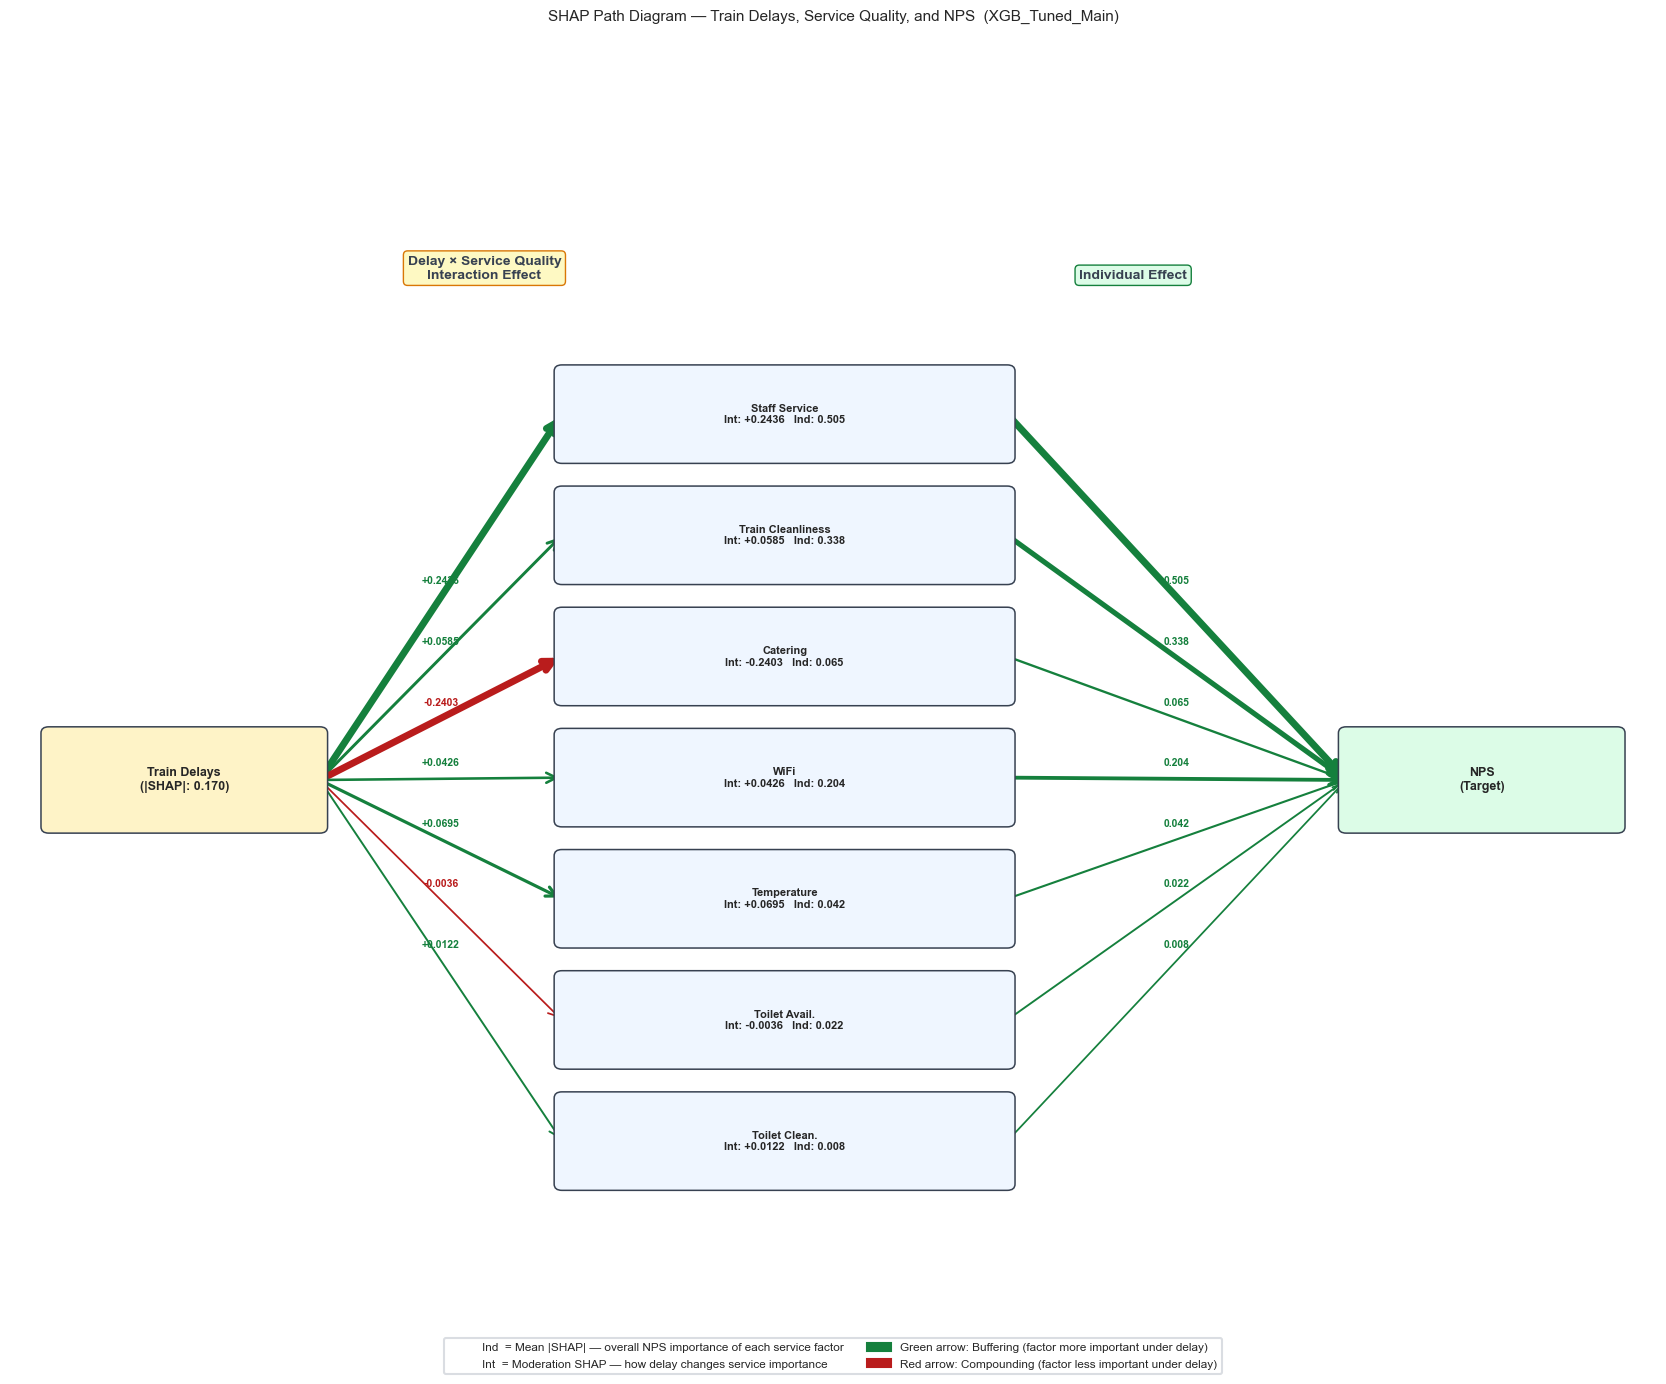

Saved: shap_path_diagram.png


In [55]:
# SECTION 12B: SHAP Path Diagram — Service Quality as Delay Moderator

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

if 'shap_df' not in dir() or 'shap_delta_df' not in dir() or 'mean_abs_shap' not in dir():
    raise RuntimeError('Run Section 12 (SHAP Analysis) first.')

SV_ORDER = [
    ('question_overall_satisfaction_overall_service_from_eurostar_staff',                    'Staff Service'),
    ('question_overall_satisfaction_cleanliness_onboard_the_train',                          'Train Cleanliness'),
    ('question_onboard_catering_met_quality_of_food_in_meal_service',                        'Catering'),
    ('question_overall_satisfaction_wifi_onboard_the_train',                                 'WiFi'),
    ('question_on_board_the_train1_the_temperature_on_board',                                'Temperature'),
    ('question_on_board_the_train1_the_availability_of_toilet_facilities_on_board',          'Toilet Avail.'),
    ('question_on_board_the_train2_the_cleanliness_of_toilet_facilities_on_board_the_train', 'Toilet Clean.'),
]

labels     = [lbl for _, lbl in SV_ORDER]
abs_lookup = dict(zip(mean_abs_shap['Feature'], mean_abs_shap['Mean_Abs_SHAP']))
indiv_shap = {lbl: float(abs_lookup.get(sv, 0.0)) for sv, lbl in SV_ORDER}
mod_lookup = dict(zip(shap_delta_df['Survey Variable'], shap_delta_df['Moderation (High-Zero)']))
mod_shap   = {lbl: mod_lookup.get(lbl, 0.0) for lbl in labels}
delay_abs  = float(abs_lookup.get(DELAY_VAR, 0.0))

max_iv  = max(abs(v) for v in indiv_shap.values()) or 1.0
max_mod = max(abs(v) for v in mod_shap.values())   or 0.001

GREEN = '#15803d'
RED   = '#b91c1c'

def mod_color(v): return GREEN if v >= 0 else RED
def arrow_lw(v, mx, wmin=1.2, wmax=5.0):
    return wmin + (wmax - wmin) * min(abs(v) / mx, 1.0)

n = len(labels)
fig, ax = plt.subplots(figsize=(17, n * 1.55 + 3.2))
H = n * 1.55 + 3.2
ax.set_xlim(0, 17); ax.set_ylim(-1.5, H); ax.axis('off')

X_L, X_M, X_R = 1.8, 8.0, 15.2
Y_C  = (n - 1) * 0.77
ys   = [i * 1.55 for i in range(n - 1, -1, -1)]
Y_TOP = ys[0] + 1.4   # y position for column headers

# ── Column headers ────────────────────────────────────────────────────────────
ax.text((X_L + X_M) / 2, Y_TOP + 0.3,
        'Delay × Service Quality\nInteraction Effect',
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef9c3', edgecolor='#d97706', lw=1))

ax.text((X_M + X_R) / 2, Y_TOP + 0.3,
        'Individual Effect',
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#dcfce7', edgecolor='#15803d', lw=1))

def draw_box(ax, cx, cy, w, h, txt, fc='#f0f4ff', fs=9):
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                                boxstyle='round,pad=0.08', linewidth=1.1,
                                edgecolor='#374151', facecolor=fc, zorder=3))
    ax.text(cx, cy, txt, ha='center', va='center', fontsize=fs,
            fontweight='bold', zorder=4)

def draw_arrow(ax, x0, y0, x1, y1, display_val, line_val, max_v, color, fmt='+'):
    w = arrow_lw(line_val, max_v)
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=w), zorder=2)
    label = f'{display_val:+.4f}' if fmt == '+' else f'{display_val:.3f}'
    ax.text((x0+x1)/2, (y0+y1)/2 + 0.14, label,
            ha='center', va='bottom', fontsize=7.5, color=color, fontweight='bold', zorder=5)

draw_box(ax, X_L, Y_C, 2.8, 1.2,
         f'Train Delays\n(|SHAP|: {delay_abs:.3f})', fc='#fef3c7')
draw_box(ax, X_R, Y_C, 2.8, 1.2, 'NPS\n(Target)', fc='#dcfce7')

for lbl, y in zip(labels, ys):
    iv  = indiv_shap.get(lbl, 0.0)
    mod = mod_shap.get(lbl, 0.0)
    draw_box(ax, X_M, y, 4.6, 1.1,
             f'{lbl}\nInt: {mod:+.4f}   Ind: {iv:.3f}',
             fc='#eff6ff', fs=8)
    draw_arrow(ax, X_L + 1.4, Y_C, X_M - 2.3, y,
               mod, mod, max_mod, mod_color(mod), fmt='+')
    draw_arrow(ax, X_M + 2.3, y, X_R - 1.4, Y_C,
               iv, iv, max_iv, GREEN, fmt='abs')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color='white', label='Ind  = Mean |SHAP| — overall NPS importance of each service factor'),
    mpatches.Patch(color='white', label='Int  = Moderation SHAP — how delay changes service importance'),
    mpatches.Patch(color=GREEN,   label='Green arrow: Buffering (factor more important under delay)'),
    mpatches.Patch(color=RED,     label='Red arrow: Compounding (factor less important under delay)'),
]
ax.legend(handles=legend_handles, loc='lower center',
          bbox_to_anchor=(0.5, -0.10), ncol=2, fontsize=8.5,
          frameon=True, edgecolor='#d1d5db')

ax.set_title(
    f'SHAP Path Diagram — Train Delays, Service Quality, and NPS  ({shap_model_label})',
    fontsize=11, pad=16)

plt.tight_layout()
plt.savefig('shap_path_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_path_diagram.png')


In [56]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy<2', '-q'])
print('NumPy downgraded. Now restart kernel.')


NumPy downgraded. Now restart kernel.
